In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as st
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import warnings
warnings.filterwarnings('ignore')


In [34]:
data= pd.read_csv('amazon_sales_dataset.csv')
data

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16


In [35]:
data.shape

(50000, 13)

In [36]:
data.isna().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

In [37]:
data.duplicated().sum()

np.int64(0)

In [38]:
data.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')

In [39]:
data.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


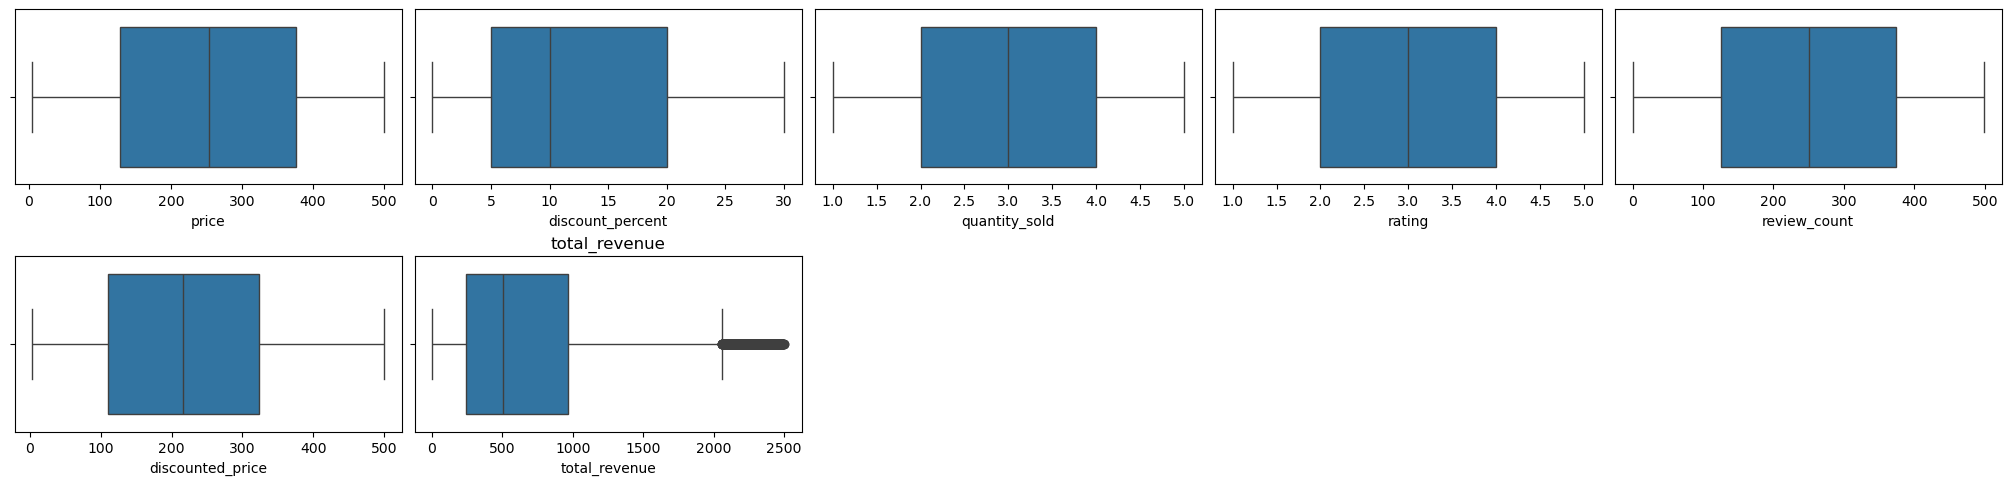

In [40]:
outliers=['price','discount_percent','quantity_sold','rating','review_count','discounted_price',
         'total_revenue']
plt.figure(figsize=(20,10),layout='constrained')

for i in range (len(outliers)):
    plt.subplot(5,5,i+1)
    sns.boxplot(data=data,x=outliers[i])


plt.title(outliers[i])
plt.show()

### OUTLIERS TREATING USING CAPPING

In [41]:
col=['price','discount_percent','quantity_sold','rating','review_count','discounted_price',
         'total_revenue']
for i in col:

    Q1 = data[i].quantile(0.25)
    Q3 = data[i].quantile(0.75)

    IQR=Q3-Q1

    # # Define lower and upper bounds

    # Define lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers (no rows removed)
    data[i] = data[i].clip(lower_bound, upper_bound)


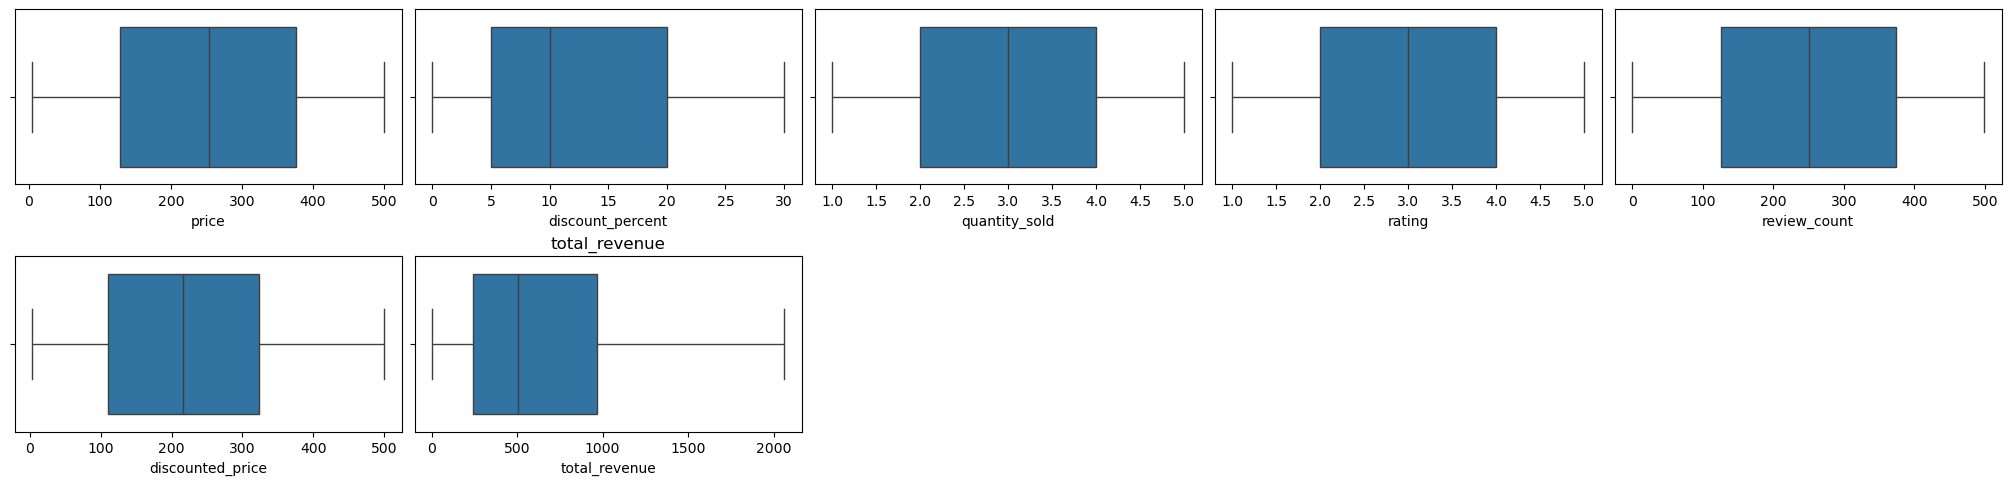

In [42]:
outliers=['price','discount_percent','quantity_sold','rating','review_count','discounted_price',
         'total_revenue']
plt.figure(figsize=(20,10),layout='constrained')

for i in range (len(outliers)):
    plt.subplot(5,5,i+1)
    sns.boxplot(data=data,x=outliers[i])


plt.title(outliers[i])
plt.show()

# PREPROCESSING

In [43]:
data

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16


In [44]:
data.shape

(50000, 13)

In [45]:
data.size

650000

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [47]:
data.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,654.978488
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,519.356606
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2061.945000


In [48]:
data=data.drop(['order_id','order_date','product_id','discounted_price'],axis=1)
data

,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,total_revenue
0,Books,128.75,10,4,North America,UPI,3.5,443,463.52
1,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,1210.40
2,Sports,495.80,20,2,Europe,UPI,4.4,183,793.28
3,Books,371.95,15,4,Middle East,UPI,5.0,212,1264.64
4,Beauty,201.68,0,4,Middle East,UPI,4.6,308,806.72
...,...,...,...,...,...,...,...,...,...
49995,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,134.95
49996,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,1324.05
49997,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,985.92
49998,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16


In [49]:
data['product_category'].unique()

array(['Books', 'Fashion', 'Sports', 'Beauty', 'Electronics',
       'Home & Kitchen'], dtype=object)

In [50]:
data['customer_region'].unique()

array(['North America', 'Asia', 'Europe', 'Middle East'], dtype=object)

In [51]:
data['payment_method'].unique()

array(['UPI', 'Credit Card', 'Wallet', 'Cash on Delivery', 'Debit Card'],
      dtype=object)

#### LabelEncoder()

In [52]:
le=LabelEncoder()
data['product_category']=le.fit_transform(data['product_category'])

In [53]:
le1=LabelEncoder()
data['customer_region']=le1.fit_transform(data['customer_region'])

In [54]:
le2=LabelEncoder()
data['payment_method']=le2.fit_transform(data['payment_method'])

In [55]:
data

,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,total_revenue
0,1,128.75,10,4,3,3,3.5,443,463.52
1,3,302.60,20,5,0,1,3.7,475,1210.40
2,5,495.80,20,2,1,3,4.4,183,793.28
3,1,371.95,15,4,2,3,5.0,212,1264.64
4,0,201.68,0,4,2,3,4.6,308,806.72
...,...,...,...,...,...,...,...,...,...
49995,0,26.99,0,5,2,1,2.4,386,134.95
49996,0,294.23,10,5,0,1,3.1,8,1324.05
49997,2,352.11,30,4,0,2,3.1,104,985.92
49998,0,307.54,5,1,2,3,1.8,316,292.16


In [56]:
data.dtypes

product_category      int64
price               float64
discount_percent      int64
quantity_sold         int64
customer_region       int64
payment_method        int64
rating              float64
review_count          int64
total_revenue       float64
dtype: object

In [57]:
data.corr()['price'].sort_values(ascending=False)   ## If correlation of Units_Sold is low → model will ignore it.

price               1.000000
total_revenue       0.713458
rating              0.006386
quantity_sold       0.004405
customer_region     0.003408
review_count        0.001282
product_category    0.000465
payment_method     -0.000837
discount_percent   -0.004654
Name: price, dtype: float64

# EDA (Exploratory Data Analysis)

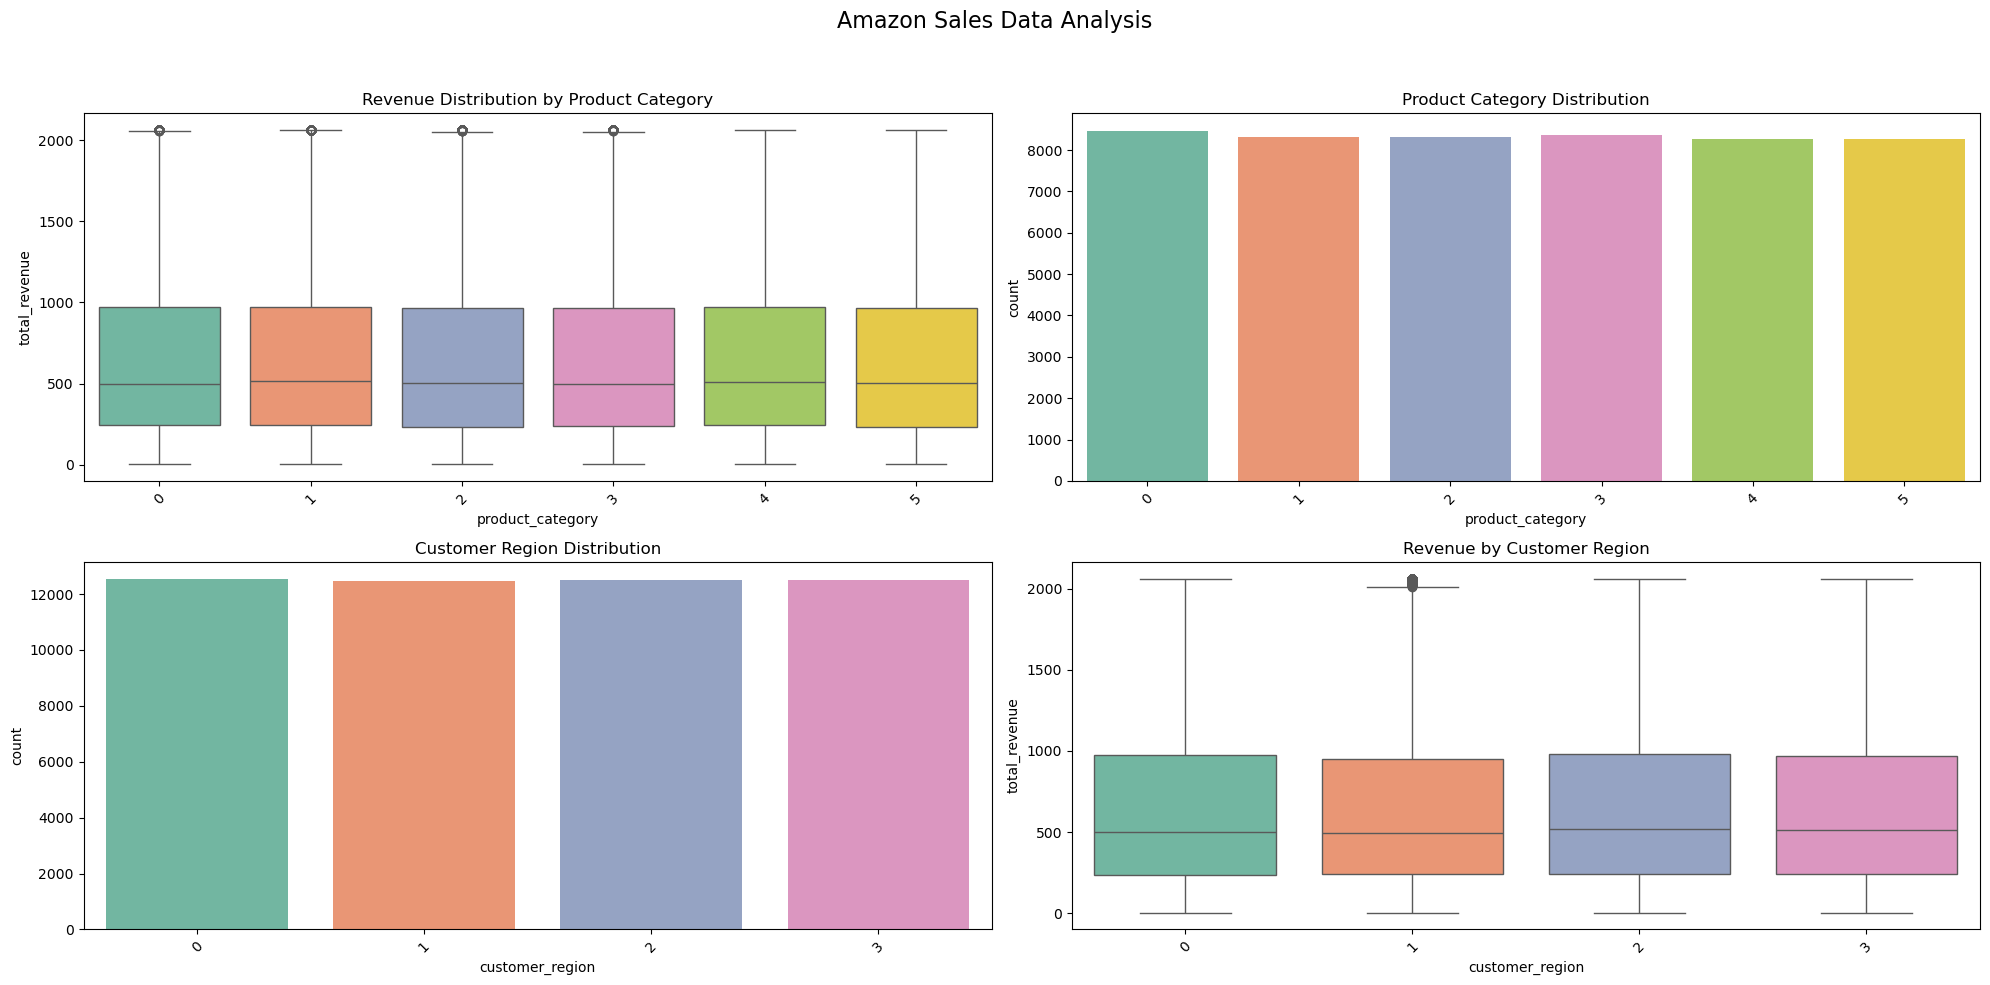

In [58]:
# Set up the figure and axes
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

fig.suptitle('Amazon Sales Data Analysis', fontsize=16)

# 1️⃣ Revenue by Product Category
sns.boxplot(
    data=data,
    x='product_category',
    y='total_revenue',
    palette='Set2',
    ax=axes[0,0]
)

axes[0,0].set_title('Revenue Distribution by Product Category')
axes[0,0].tick_params(axis='x', rotation=45)

# 2️⃣ Product Category Distribution
sns.countplot(
    data=data,
    x='product_category',
    palette='Set2',
    ax=axes[0,1]
)

axes[0,1].set_title('Product Category Distribution')
axes[0,1].tick_params(axis='x', rotation=45)

# 3️⃣ Customer Region Distribution
sns.countplot(
    data=data,
    x='customer_region',
    palette='Set2',
    ax=axes[1,0]
)

axes[1,0].set_title('Customer Region Distribution')
axes[1,0].tick_params(axis='x', rotation=45)

# 4️⃣ Revenue by Customer Region
sns.boxplot(
    data=data,
    x='customer_region',
    y='total_revenue',
    palette='Set2',
    ax=axes[1,1]
)

axes[1,1].set_title('Revenue by Customer Region')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0,0,1,0.95])

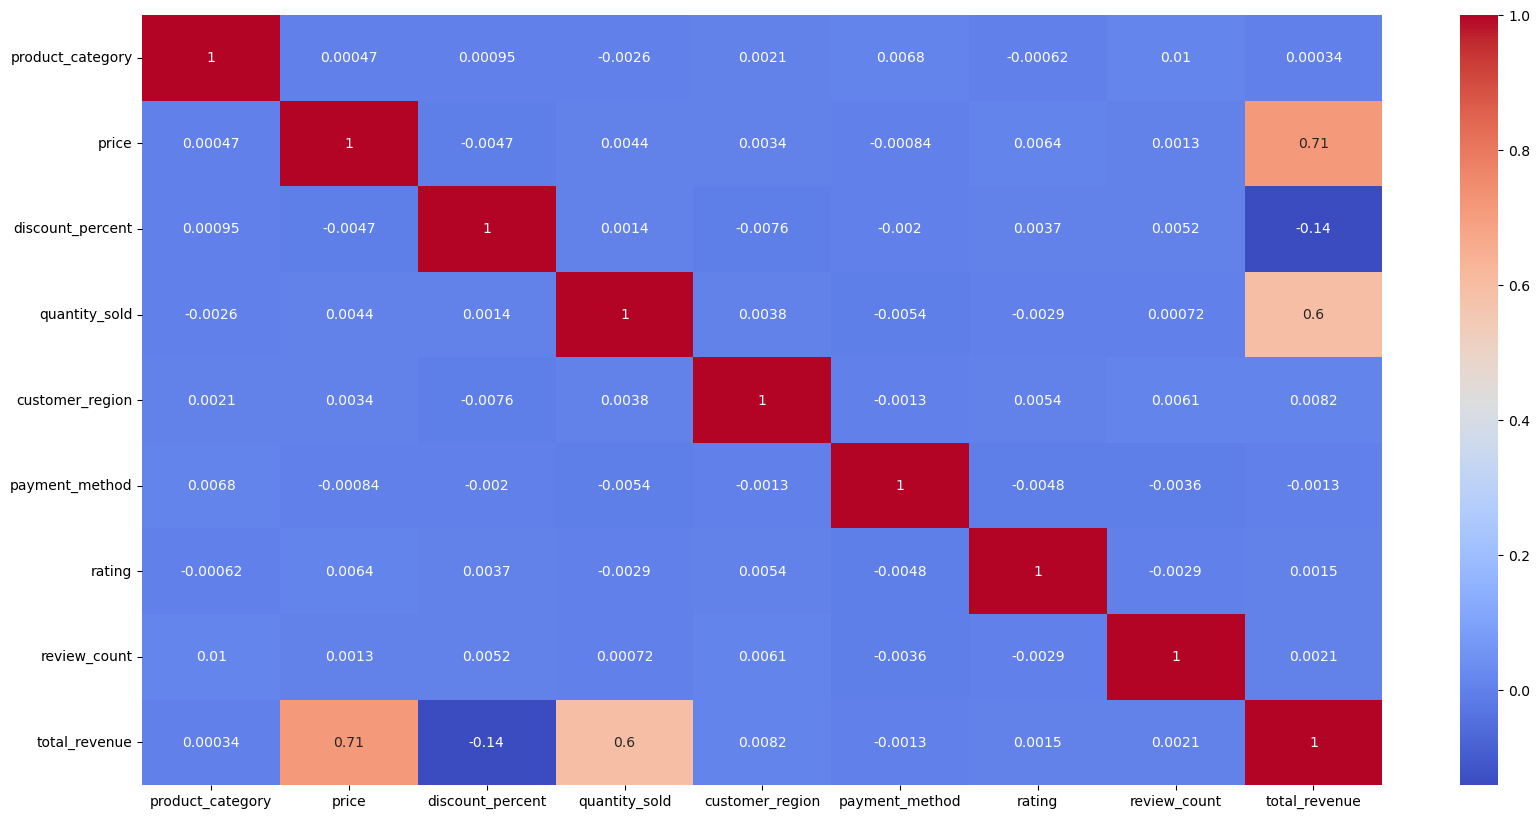

In [59]:
plt.figure(figsize=(20,10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

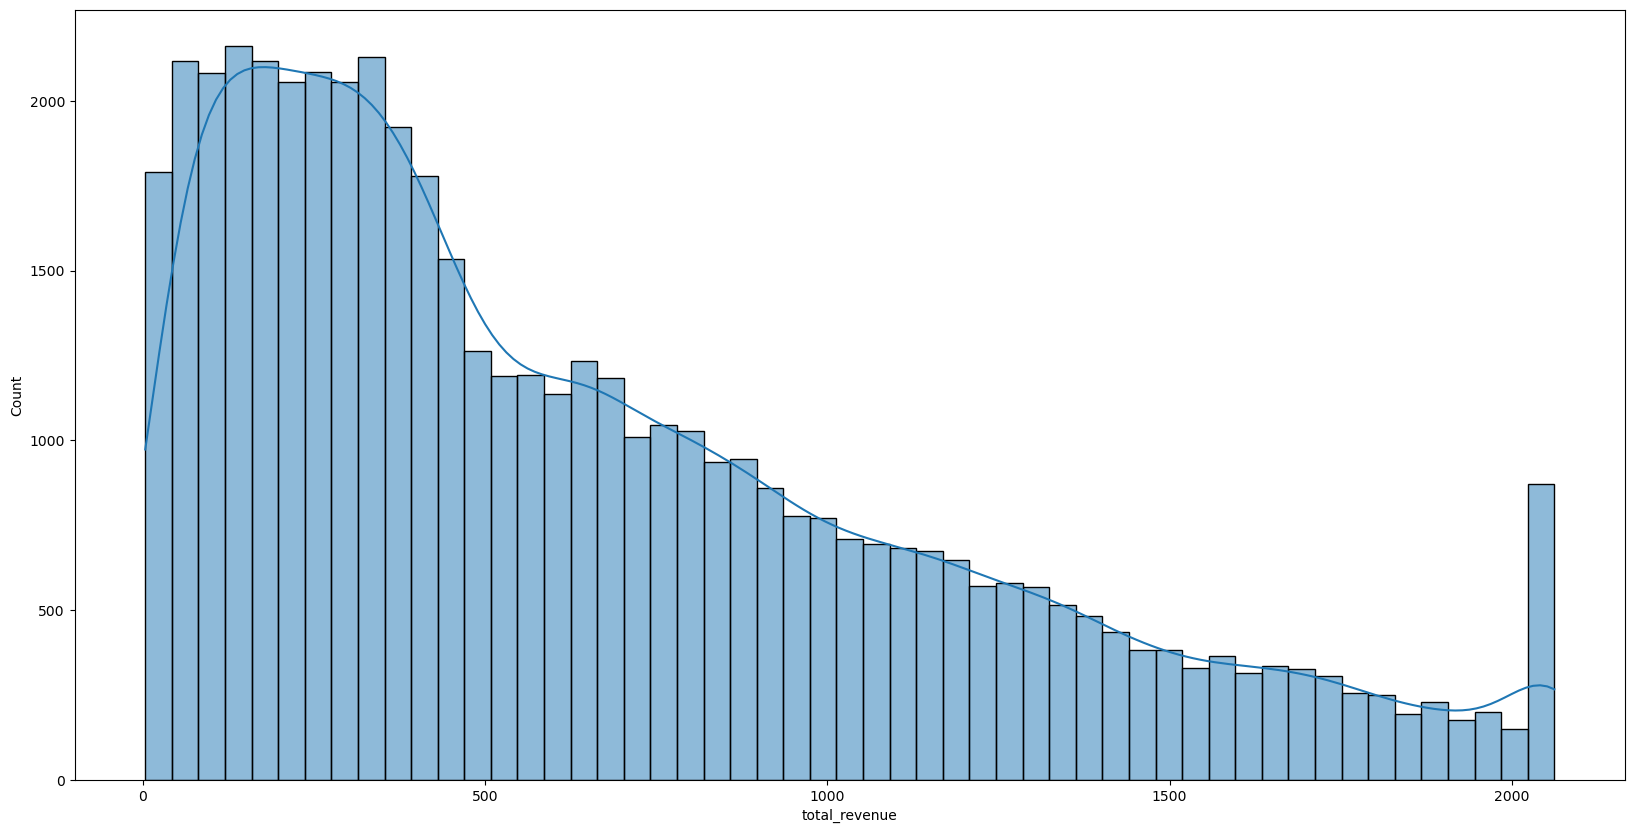

In [60]:
plt.figure(figsize=(20,10))
sns.histplot(data['total_revenue'], kde=True)
plt.show()

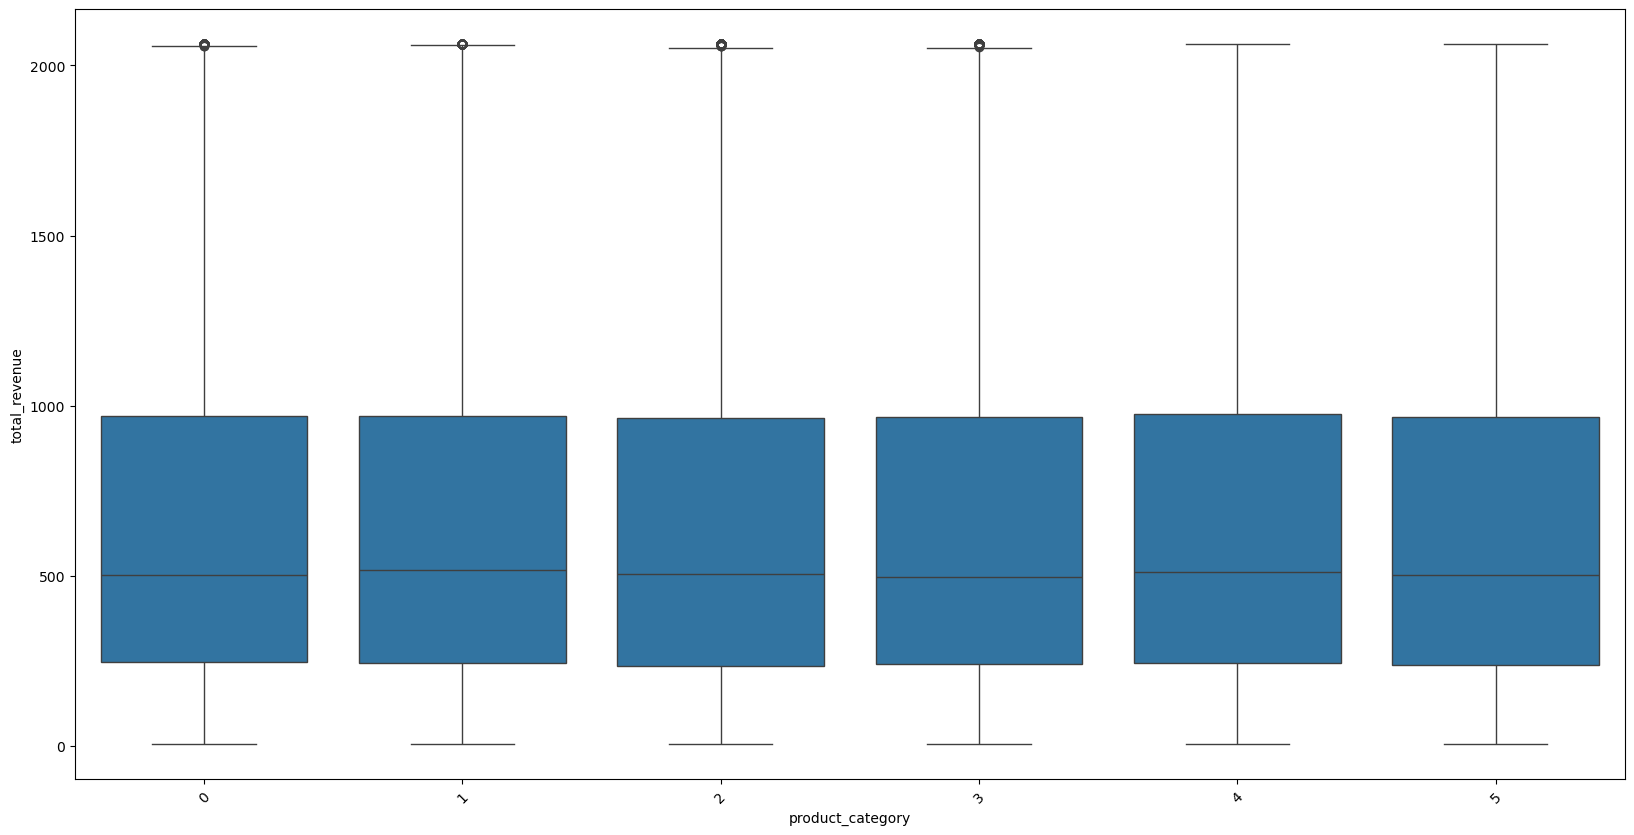

In [61]:
plt.figure(figsize=(20,10))
sns.boxplot(x='product_category', y='total_revenue', data=data)
plt.xticks(rotation=45)
plt.show()

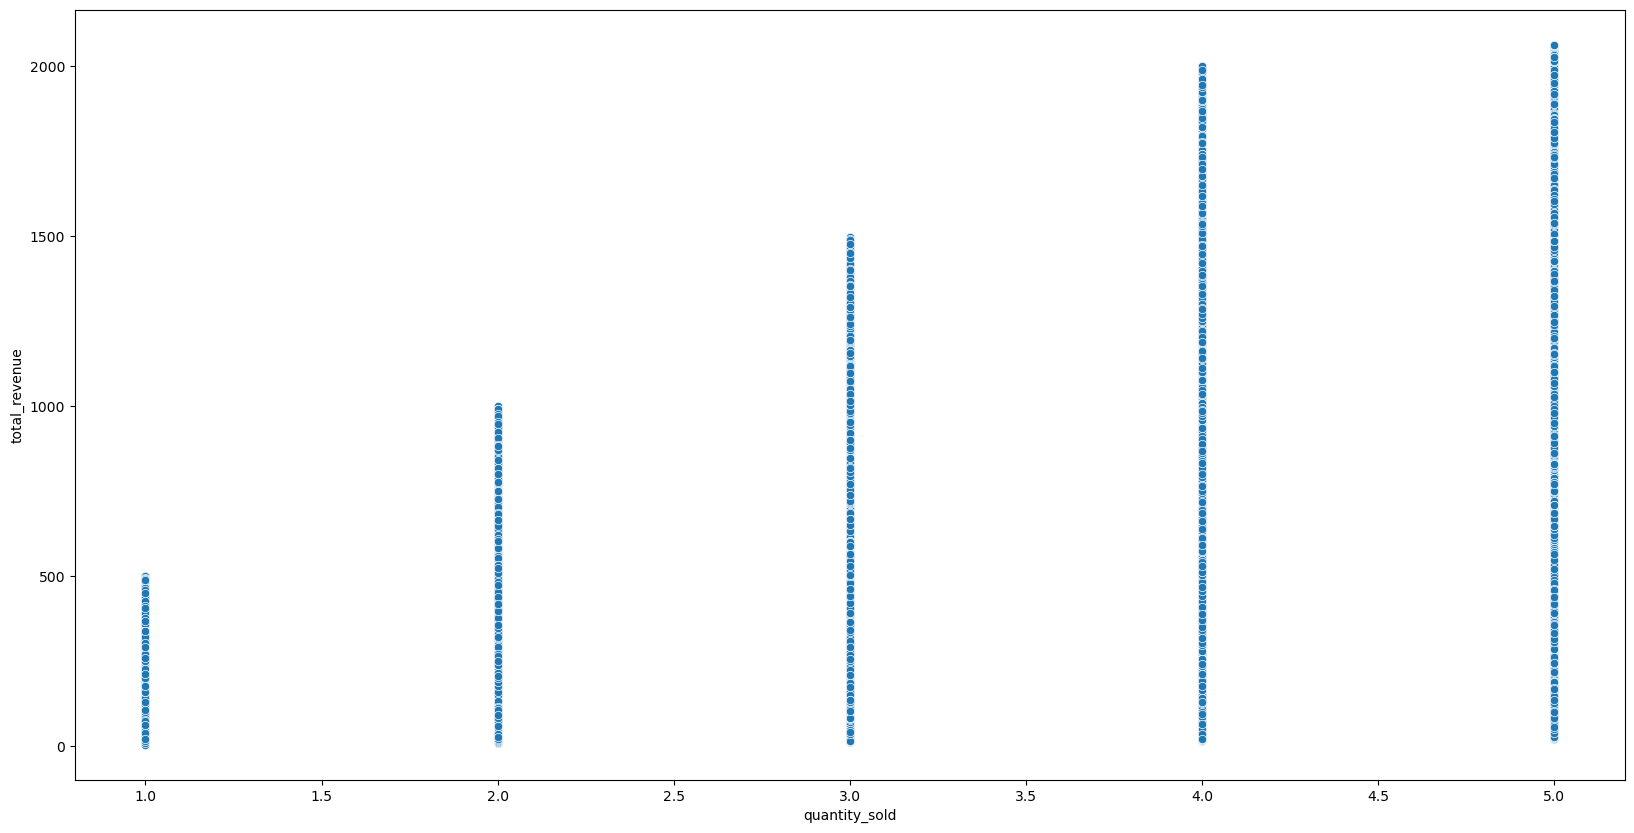

In [62]:
plt.figure(figsize=(20,10))
sns.scatterplot(x='quantity_sold', y='total_revenue', data=data)
plt.show()

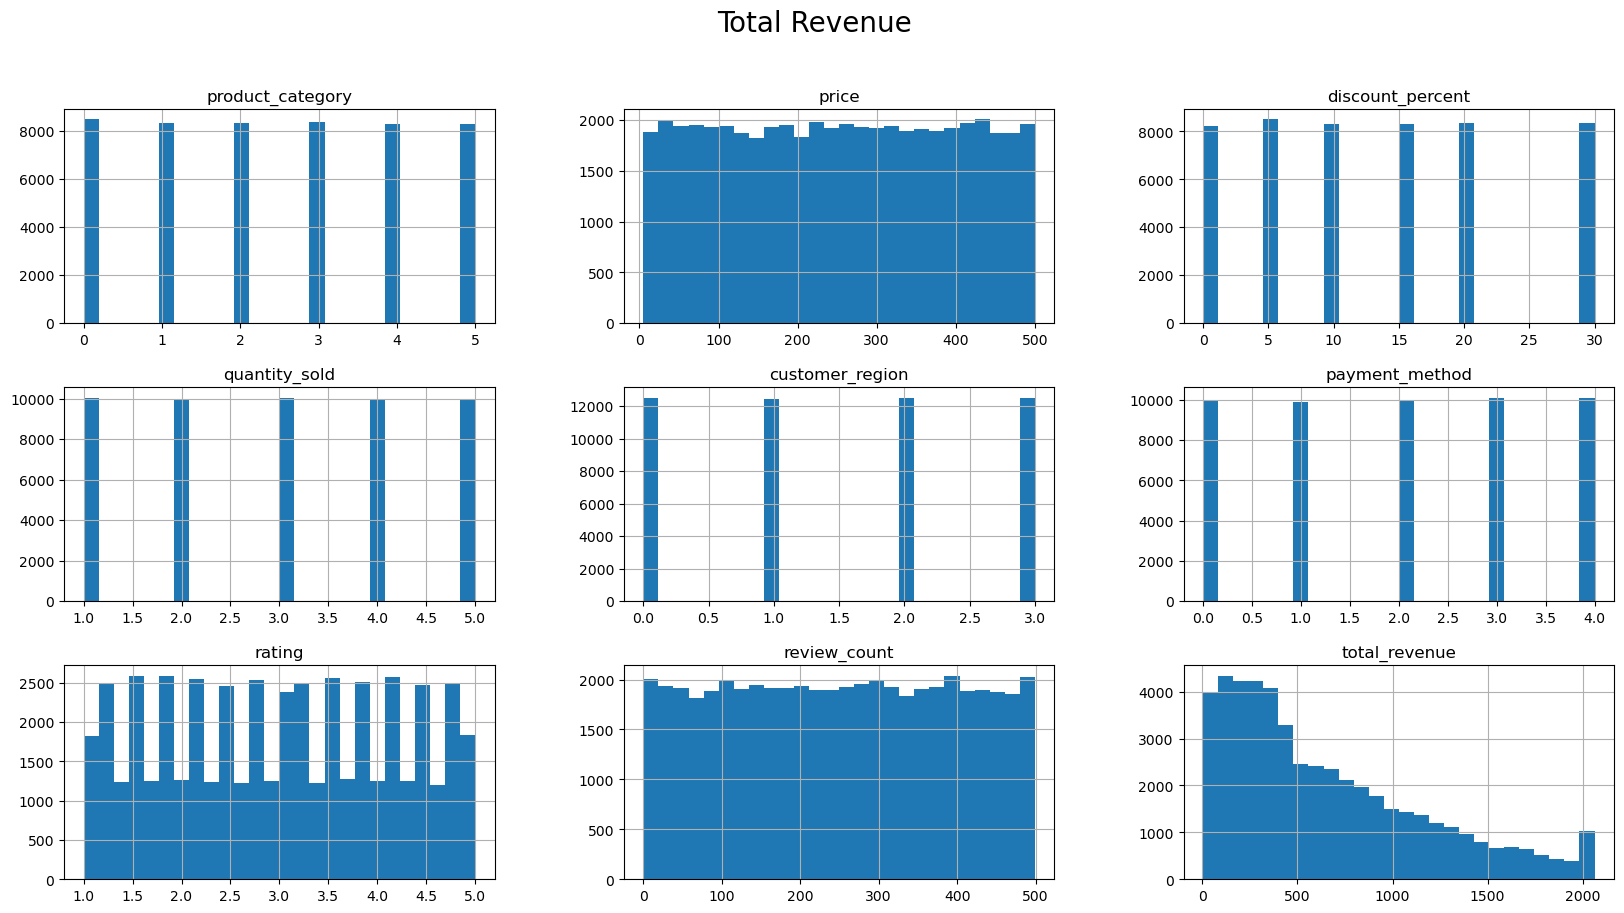

In [63]:
# HISTPLOT

data.hist(figsize=(20, 10), bins=26)
plt.suptitle('Total Revenue', fontsize=20)
plt.show()

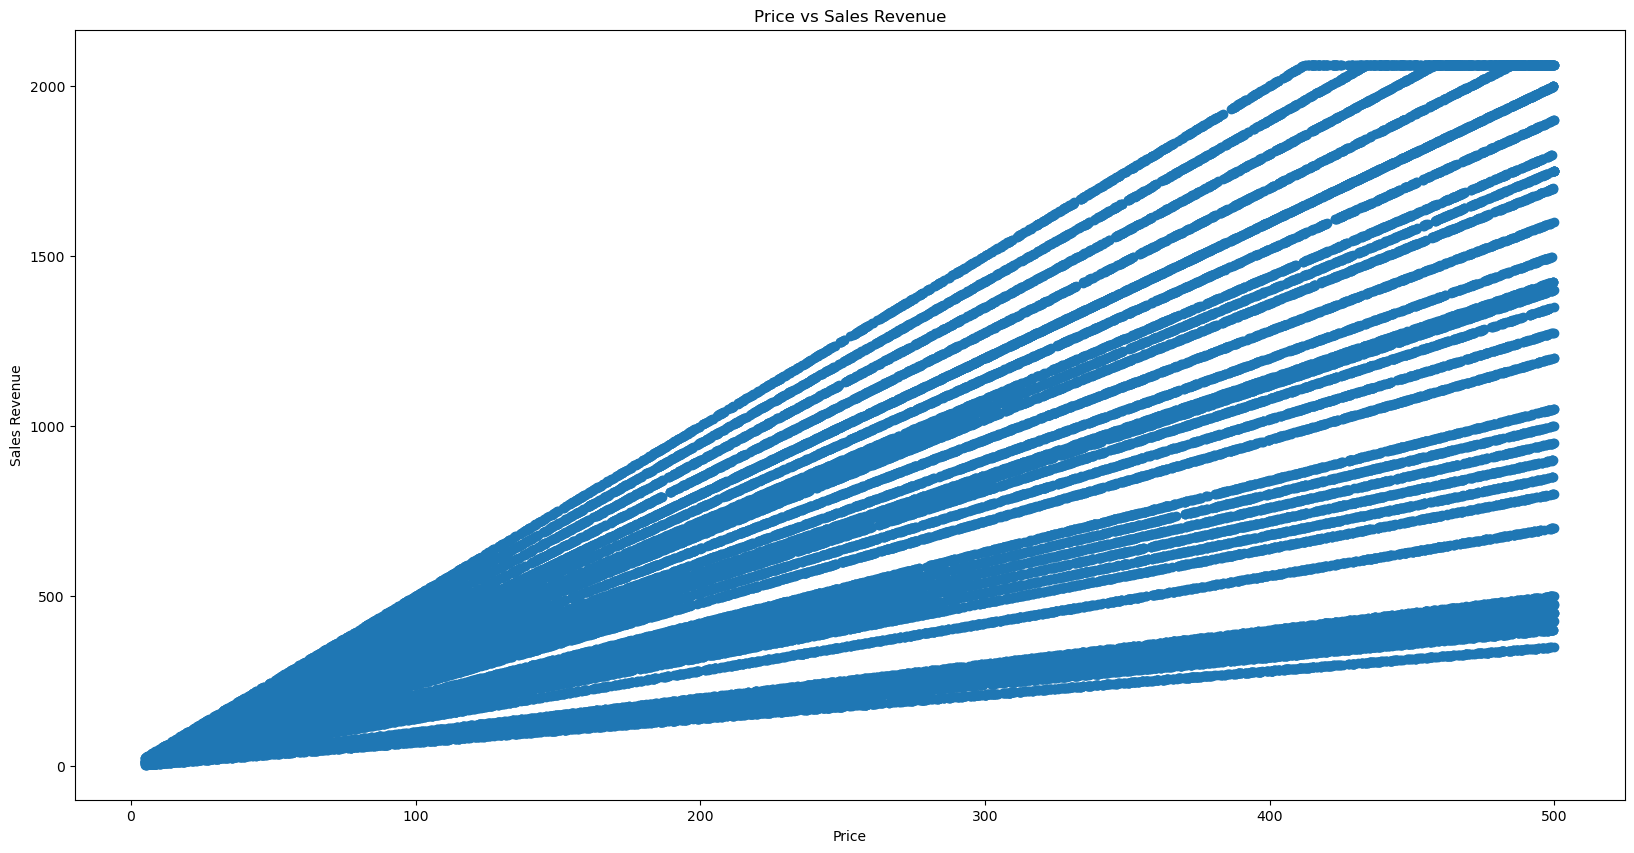

In [64]:
plt.figure(figsize=(20,10))
plt.scatter(data['price'], data['total_revenue'])
plt.xlabel('Price')
plt.ylabel('Sales Revenue')
plt.title('Price vs Sales Revenue')
plt.show()

# This scatter plot shows the relationship between Price and Sales Revenue. We can observe whether a linear or non-linear pattern exists.

# SPLITTING THE DATA

In [65]:
x=data.drop('total_revenue',axis=1)
y=data.total_revenue
x

,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count
0,1,128.75,10,4,3,3,3.5,443
1,3,302.60,20,5,0,1,3.7,475
2,5,495.80,20,2,1,3,4.4,183
3,1,371.95,15,4,2,3,5.0,212
4,0,201.68,0,4,2,3,4.6,308
...,...,...,...,...,...,...,...,...
49995,0,26.99,0,5,2,1,2.4,386
49996,0,294.23,10,5,0,1,3.1,8
49997,2,352.11,30,4,0,2,3.1,104
49998,0,307.54,5,1,2,3,1.8,316


In [66]:
y

0         463.52
1        1210.40
2         793.28
3        1264.64
4         806.72
          ...   
49995     134.95
49996    1324.05
49997     985.92
49998     292.16
49999     177.41
Name: total_revenue, Length: 50000, dtype: float64

# TRAIN_TEST_SPLIT

In [67]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=50)


# SCALING

In [68]:
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

# LINEAR REGRESSION ALGORITHAM

###### Used when the relationship between X and y is linear.

###### Linear Regression models the relationship between independent variables (X) and a continuous dependent variable (y) using a straight line.

###### Assumes straight-line relationship

###### Sensitive to outliers

In [69]:
lr_model=LinearRegression()
lr_model.fit(x_train,y_train)


LinearRegression()

In [70]:
y_pred_test=lr_model.predict(x_test)
y_pred_train=lr_model.predict(x_train)


In [71]:
print("\nLinear Regression Performance\n")
print(f"Train Score              : {lr_model.score(x_train, y_train):.4f}")
print(f"Test Score               : {lr_model.score(x_test, y_test):.4f}")
print(f"MSE                      : {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"MAE                      : {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"R² Score (Test Data)     : {r2_score(y_test, y_pred_test):.4f}")
print(f"Root Mean Squared Error  : {np.sqrt(mean_squared_error(y_test,y_pred_test)):.4f}")


Linear Regression Performance

Train Score              : 0.8801
Test Score               : 0.8788
MSE                      : 32898.1949
MAE                      : 136.3504
R² Score (Test Data)     : 0.8788
Root Mean Squared Error  : 181.3786



Linear Regression Visualizations



<Axes: xlabel='total_revenue', ylabel='Count'>

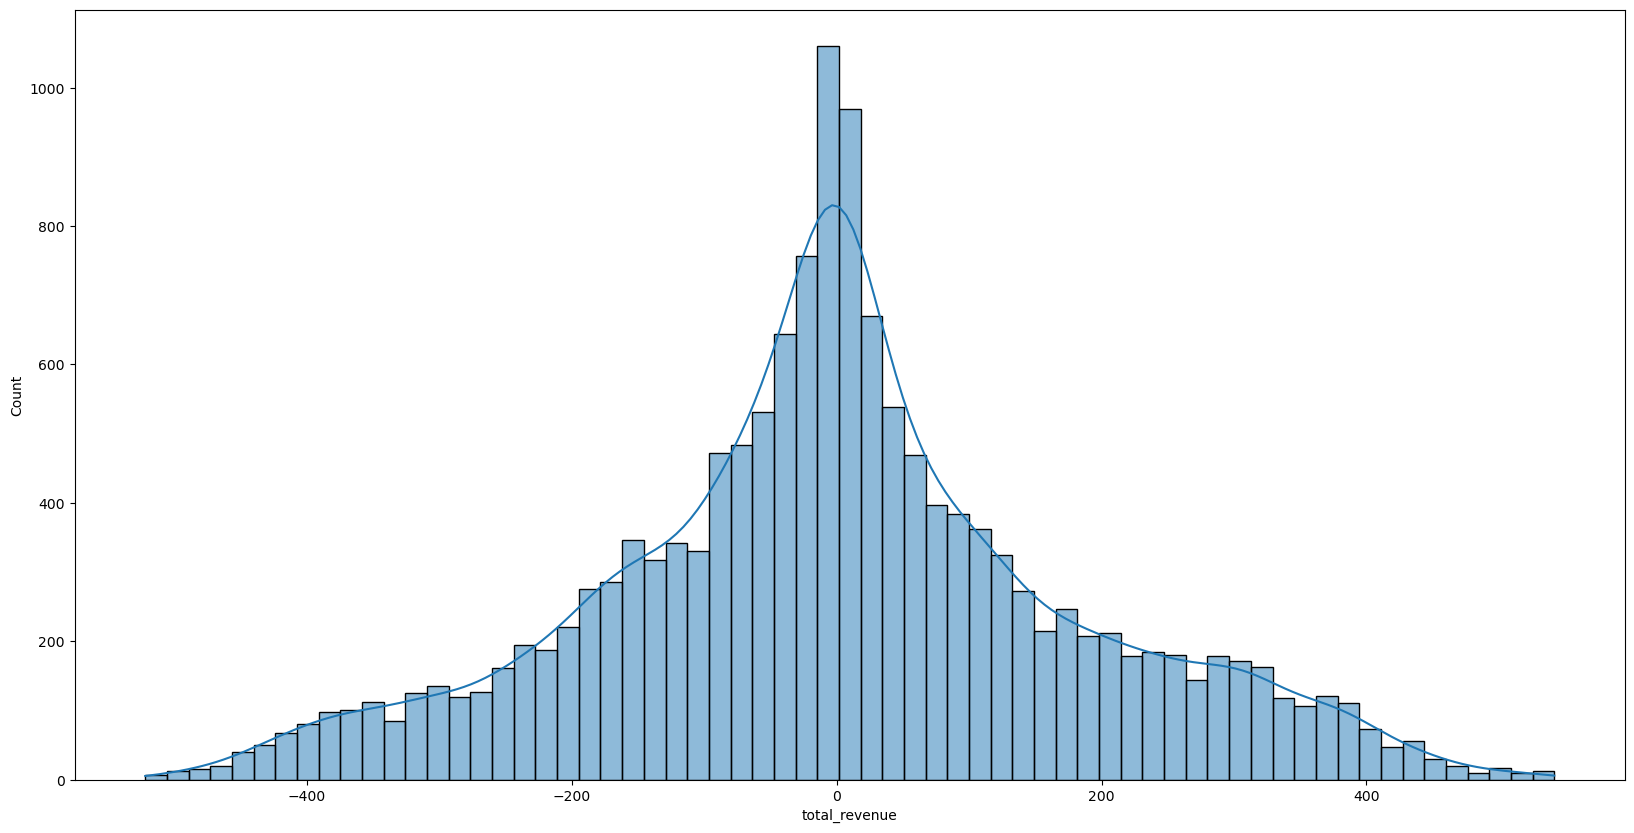

In [72]:
print("\nLinear Regression Visualizations\n")

plt.figure(figsize=(20,10))
residuals = y_test - y_pred_test
sns.histplot(residuals, kde=True)

# DECISION TREE ALGORITHAM

###### It works by splitting data step-by-step based on feature values to make predictions.

In [73]:
dt_model=DecisionTreeRegressor(criterion='friedman_mse',random_state=42)
dt_model.fit(x_train,y_train)


DecisionTreeRegressor(criterion='friedman_mse', random_state=42)

In [74]:
y_pred_test=dt_model.predict(x_test)
y_pred_train=dt_model.predict(x_train)


In [75]:

print("\nDecision Tree Regression Performance\n")
print(f"Train Score              : {dt_model.score(x_train, y_train):.4f}")
print(f"Test Score               : {dt_model.score(x_test, y_test):.4f}")
print(f"MSE                      : {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"MAE                      : {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"R² Score (Test Data)     : {r2_score(y_test, y_pred_test):.4f}")
print(f"Root Mean Squared Error  : {np.sqrt(mean_squared_error(y_test,y_pred_test)):.4f}")


Decision Tree Regression Performance

Train Score              : 1.0000
Test Score               : 1.0000
MSE                      : 4.4177
MAE                      : 1.2508
R² Score (Test Data)     : 1.0000
Root Mean Squared Error  : 2.1018



Decision Tree Regression Visualizations



<Axes: xlabel='total_revenue', ylabel='Count'>

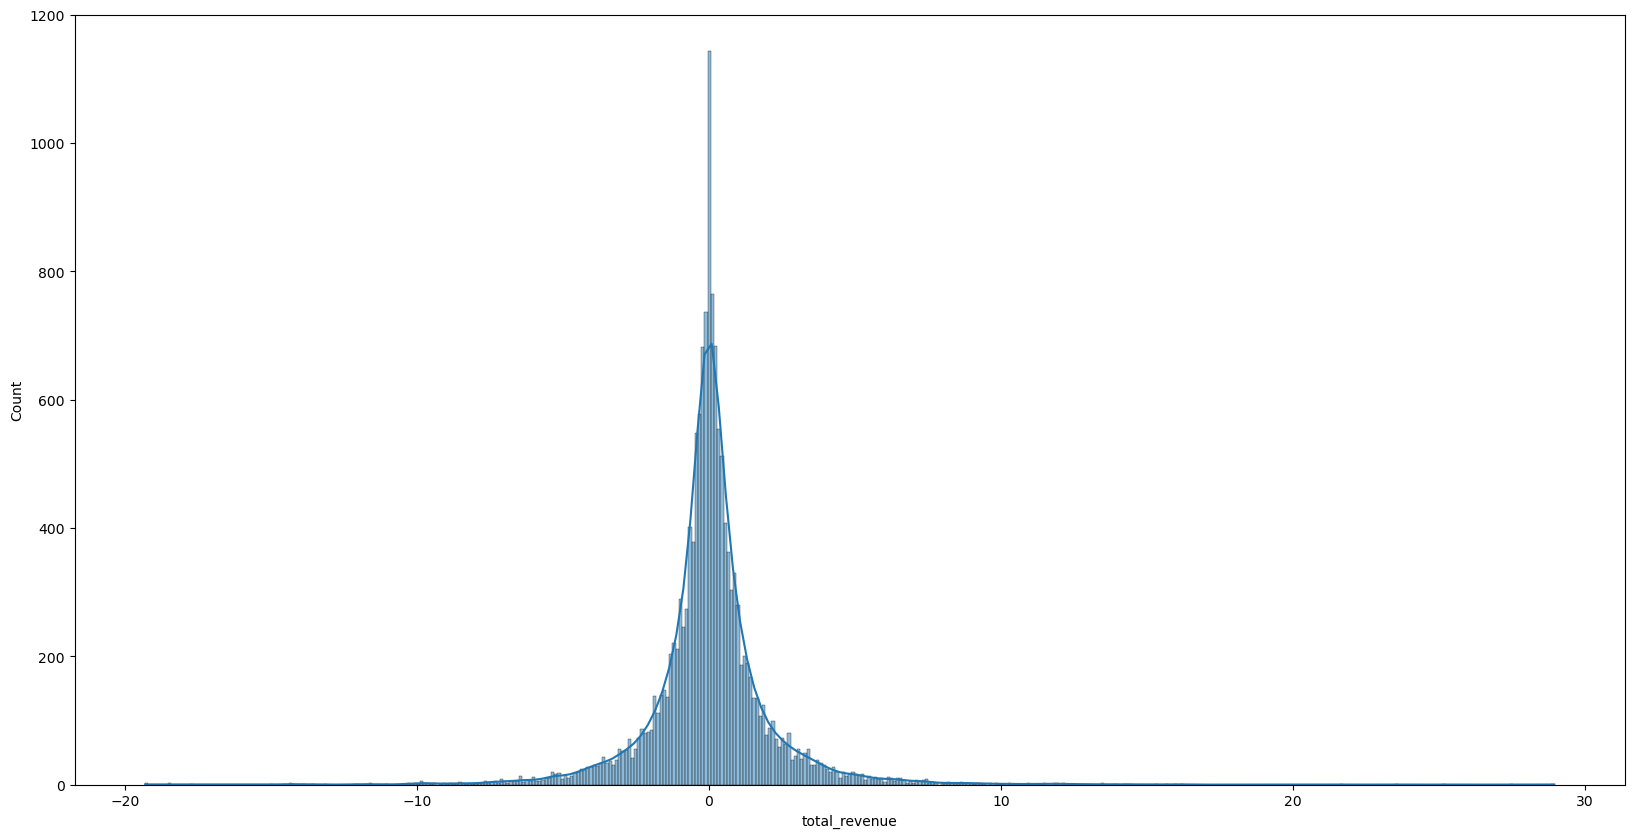

In [76]:
print("\nDecision Tree Regression Visualizations\n")

plt.figure(figsize=(20,10))
residuals = y_test - y_pred_test
sns.histplot(residuals, kde=True)

# RANDOM FOREST ALGORITHAM

###### Random Forest Regressor is an ensemble learning algorithm

###### lower overfitting, better generalization than a single tree

In [77]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,          # VERY IMPORTANT
    random_state=42
)
rf_model.fit(x_train,y_train)


RandomForestRegressor(max_depth=10, random_state=42)

In [78]:
y_pred_test=rf_model.predict(x_test)
y_pred_train=rf_model.predict(x_train)

In [79]:
print("\nRandom Forest Regression Performance\n")
print(f"Train Score              : {rf_model.score(x_train, y_train):.4f}")
print(f"Test Score               : {rf_model.score(x_test, y_test):.4f}")
print(f"MSE                      : {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"MAE                      : {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"R² Score (Test Data)     : {r2_score(y_test, y_pred_test):.4f}")
print(f"Root Mean Squared Error  : {np.sqrt(mean_squared_error(y_test,y_pred_test)):.4f}")


Random Forest Regression Performance

Train Score              : 0.9999
Test Score               : 0.9998
MSE                      : 43.2393
MAE                      : 4.2801
R² Score (Test Data)     : 0.9998
Root Mean Squared Error  : 6.5757



Random Forest Regression Visualizations



<Axes: xlabel='total_revenue', ylabel='Count'>

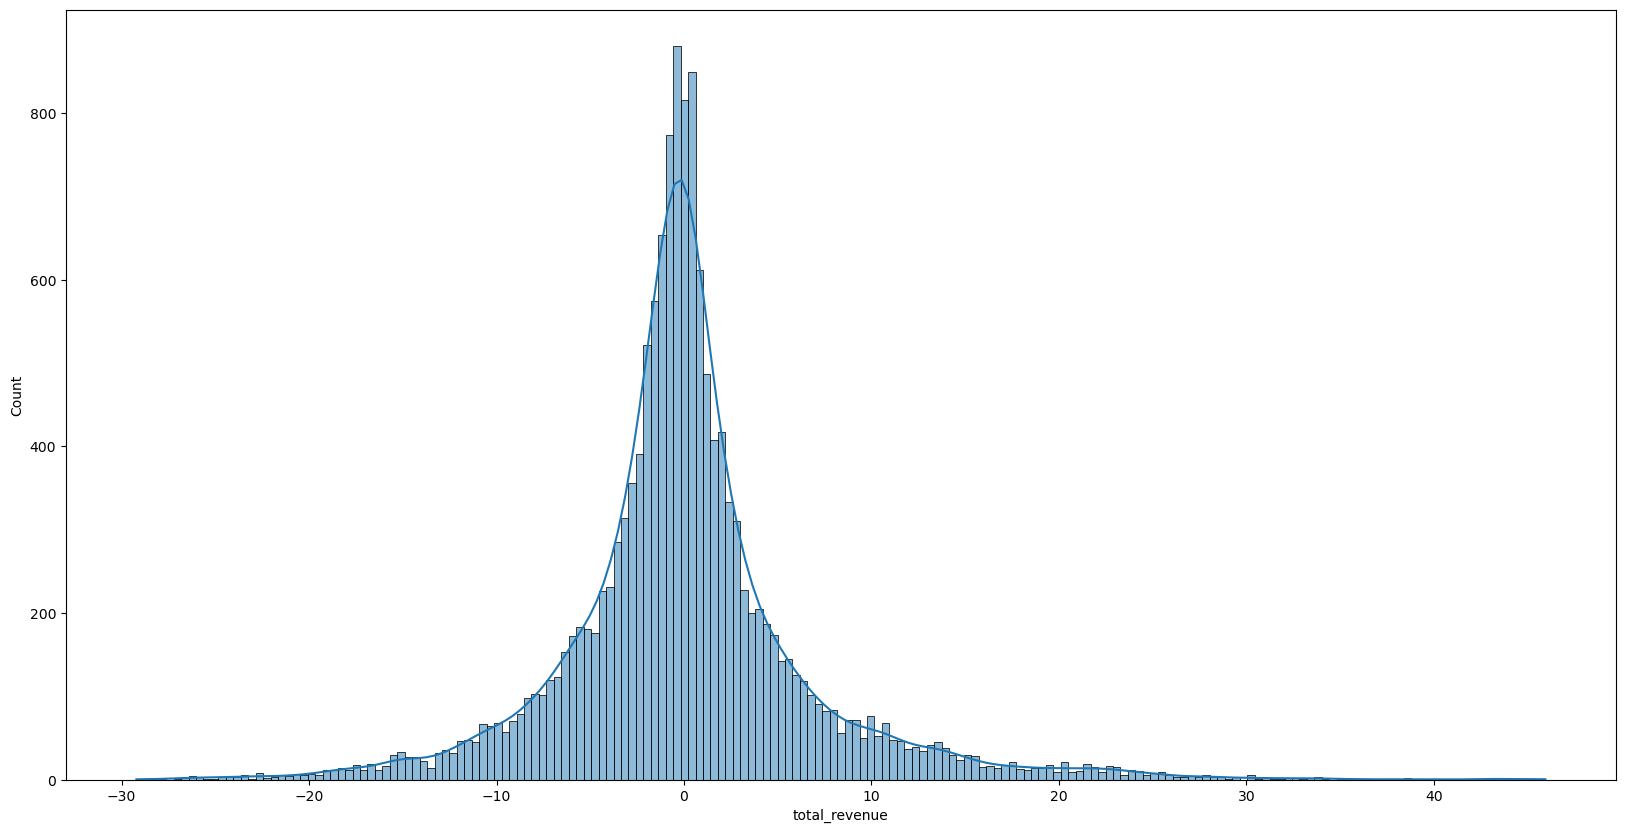

In [80]:
print("\nRandom Forest Regression Visualizations\n")

plt.figure(figsize=(20,10))
residuals = y_test - y_pred_test
sns.histplot(residuals, kde=True)

# X_G BOOST ALGORITHAM
##### XGBoost (Extreme Gradient Boosting) is an advanced boosting algorithm based on decision trees

In [81]:
xgb_model=XGBRegressor(n_estimators=200, learning_rate=0.05,random_state=42)
xgb_model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [82]:
y_pred_test=xgb_model.predict(x_test)
y_pred_train=xgb_model.predict(x_train)

In [83]:
print("\nX_G BOOST Performance\n")
print(f"Train Score              : {xgb_model.score(x_train, y_train):.4f}")
print(f"Test Score               : {xgb_model.score(x_test, y_test):.4f}")
print(f"MSE                      : {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"MAE                      : {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"R² Score (Test Data)     : {r2_score(y_test, y_pred_test):.4f}")
print(f"Root Mean Squared Error  : {np.sqrt(mean_squared_error(y_test,y_pred_test)):.4f}")


X_G BOOST Performance

Train Score              : 0.9999
Test Score               : 0.9999
MSE                      : 21.7272
MAE                      : 3.2591
R² Score (Test Data)     : 0.9999
Root Mean Squared Error  : 4.6612



X_G BOOST Visualizations



<Axes: xlabel='total_revenue', ylabel='Count'>

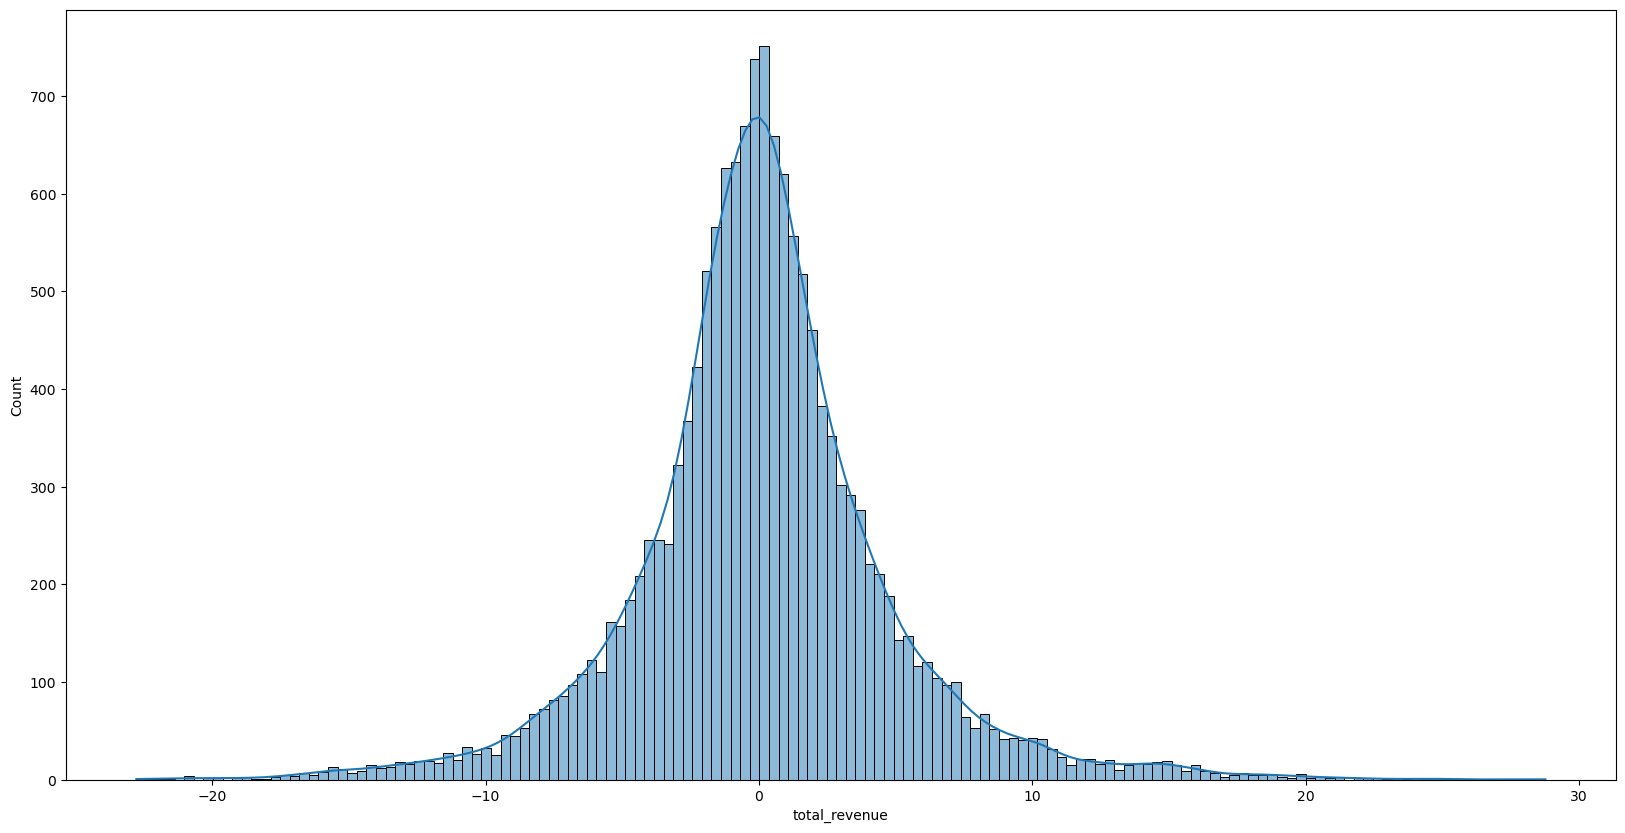

In [84]:
print("\nX_G BOOST Visualizations\n")

plt.figure(figsize=(20,10))
residuals = y_test - y_pred_test
sns.histplot(residuals, kde=True)

# SVM (Support Vector Machine) ALGORITHAM
###### It works by finding the optimal boundary (hyperplane) that maximizes the margin between data points.

In [85]:
svm_model = SVR(
    kernel='linear',   # Linear kernel
    C=1,               # Regularization parameter
    epsilon=0.1,       # Defines margin of tolerance where no penalty is given.
    max_iter=10000     # Maximum iterations for optimization
)
svm_model.fit(x_train, y_train)

SVR(C=1, kernel='linear', max_iter=10000)

In [86]:
y_pred_test=svm_model.predict(x_test)
y_pred_train=svm_model.predict(x_train)

In [87]:
print("\nSVM (Support Vector Machine) Performance\n")
print(f"Train Score              : {svm_model.score(x_train, y_train):.4f}")
print(f"Test Score               : {svm_model.score(x_test, y_test):.4f}")
print(f"MSE                      : {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"MAE                      : {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"R² Score (Test Data)     : {r2_score(y_test, y_pred_test):.4f}")
print(f"Root Mean Squared Error  : {np.sqrt(mean_squared_error(y_test,y_pred_test)):.4f}")



SVM (Support Vector Machine) Performance

Train Score              : 0.8630
Test Score               : 0.8616
MSE                      : 37571.7992
MAE                      : 149.9441
R² Score (Test Data)     : 0.8616
Root Mean Squared Error  : 193.8345



KNN (K-Nearest Neighbors) Visualizations



<Axes: xlabel='total_revenue', ylabel='Count'>

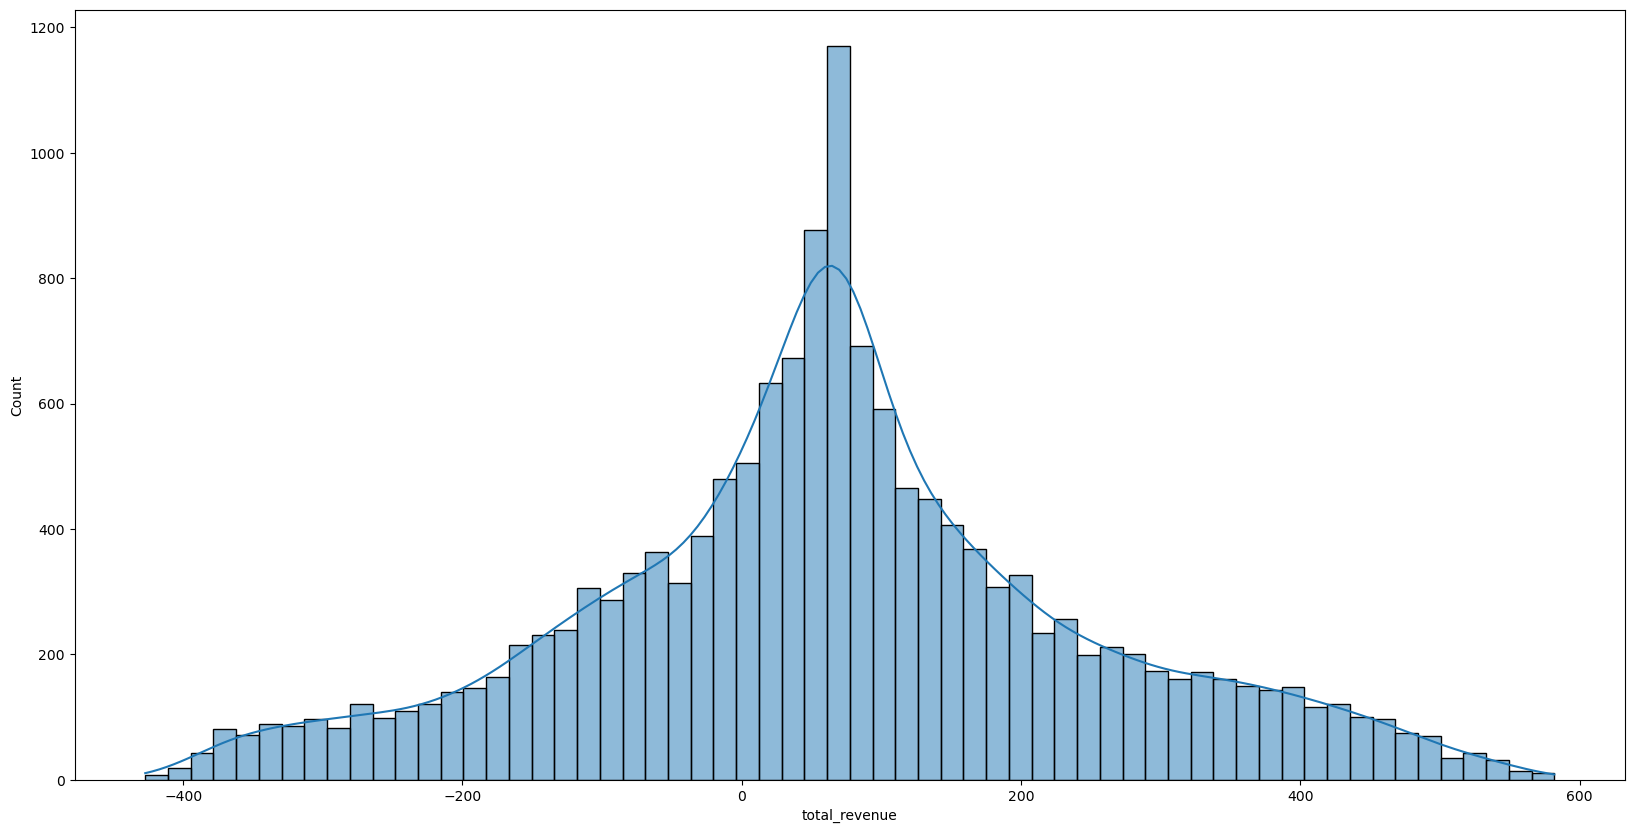

In [88]:
print("\nKNN (K-Nearest Neighbors) Visualizations\n")

plt.figure(figsize=(20,10))
residuals = y_test - y_pred_test
sns.histplot(residuals, kde=True)

# KNN (K-Nearest Neighbors) ALGORITHAM
###### KNN works by “looking at neighbors”.
###### For a new data point, it finds the K closest points in training data.

In [89]:
knn_model=KNeighborsRegressor(n_neighbors=5, n_jobs=-1 )
knn_model.fit(x_train,y_train)

KNeighborsRegressor(n_jobs=-1)

In [90]:
y_pred_test=knn_model.predict(x_test)
y_pred_train=knn_model.predict(x_train)

In [91]:
print("\nKNN (K-Nearest Neighbors) Performance\n")
print(f"Train Score              : {knn_model.score(x_train, y_train):.4f}")
print(f"Test Score               : {knn_model.score(x_test, y_test):.4f}")
print(f"MSE                      : {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"MAE                      : {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"R² Score (Test Data)     : {r2_score(y_test, y_pred_test):.4f}")
print(f"Root Mean Squared Error  : {np.sqrt(mean_squared_error(y_test,y_pred_test)):.4f}")
n_jobs=-1


KNN (K-Nearest Neighbors) Performance

Train Score              : 0.9762
Test Score               : 0.9668
MSE                      : 9008.8289
MAE                      : 71.4327
R² Score (Test Data)     : 0.9668
Root Mean Squared Error  : 94.9149



KNN (K-Nearest Neighbors) Visualizations



<Axes: xlabel='total_revenue', ylabel='Count'>

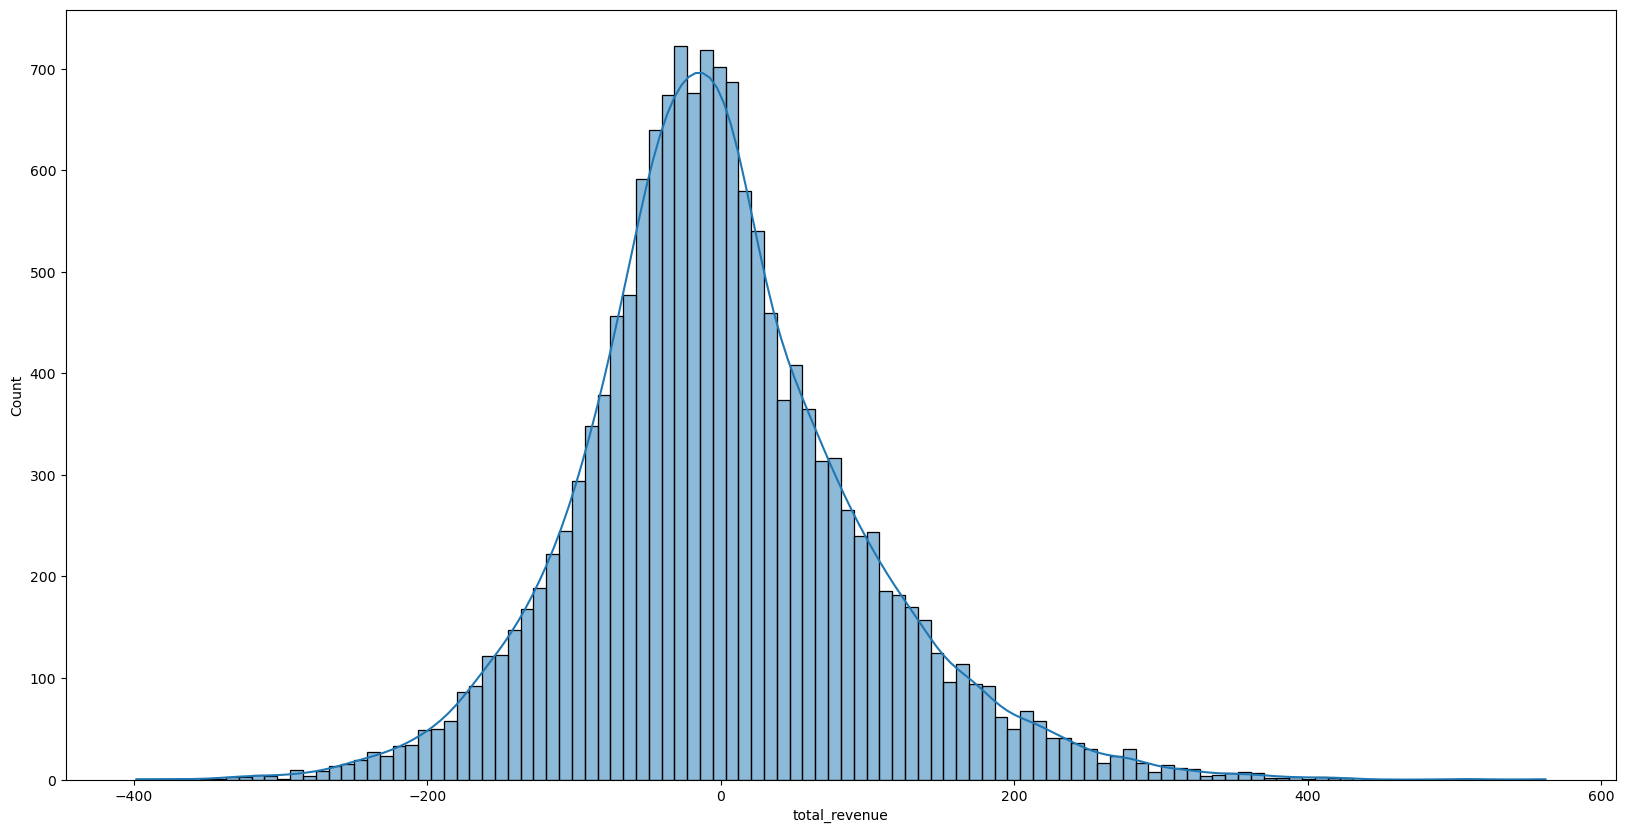

In [92]:
print("\nKNN (K-Nearest Neighbors) Visualizations\n")

plt.figure(figsize=(20,10))
residuals = y_test - y_pred_test
sns.histplot(residuals, kde=True)

# ADABOOST ALGORITHAM
###### it’s an ensemble method that combines multiple weak learners to form a strong model.
###### Misclassified samples in previous iterations get higher weight
###### Next weak learner tries to correct these errors

In [93]:
ada_model=AdaBoostRegressor(n_estimators=1000,learning_rate=0.1,random_state=50)
ada_model.fit(x_train,y_train)


AdaBoostRegressor(learning_rate=0.1, n_estimators=1000, random_state=50)

In [94]:
y_pred_test=ada_model.predict(x_test)
y_pred_train=ada_model.predict(x_train)

In [95]:
print("\nADABOOST Performance\n")
print(f"Train Score              : {ada_model.score(x_train, y_train):.4f}")
print(f"Test Score               : {ada_model.score(x_test, y_test):.4f}")
print(f"MSE                      : {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"MAE                      : {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"R² Score (Test Data)     : {r2_score(y_test, y_pred_test):.4f}")
print(f"Root Mean Squared Error  : {np.sqrt(mean_squared_error(y_test,y_pred_test)):.4f}")



ADABOOST Performance

Train Score              : 0.9459
Test Score               : 0.9453
MSE                      : 14849.6658
MAE                      : 102.1787
R² Score (Test Data)     : 0.9453
Root Mean Squared Error  : 121.8592



ADABOOST Visualizations



<Axes: xlabel='total_revenue', ylabel='Count'>

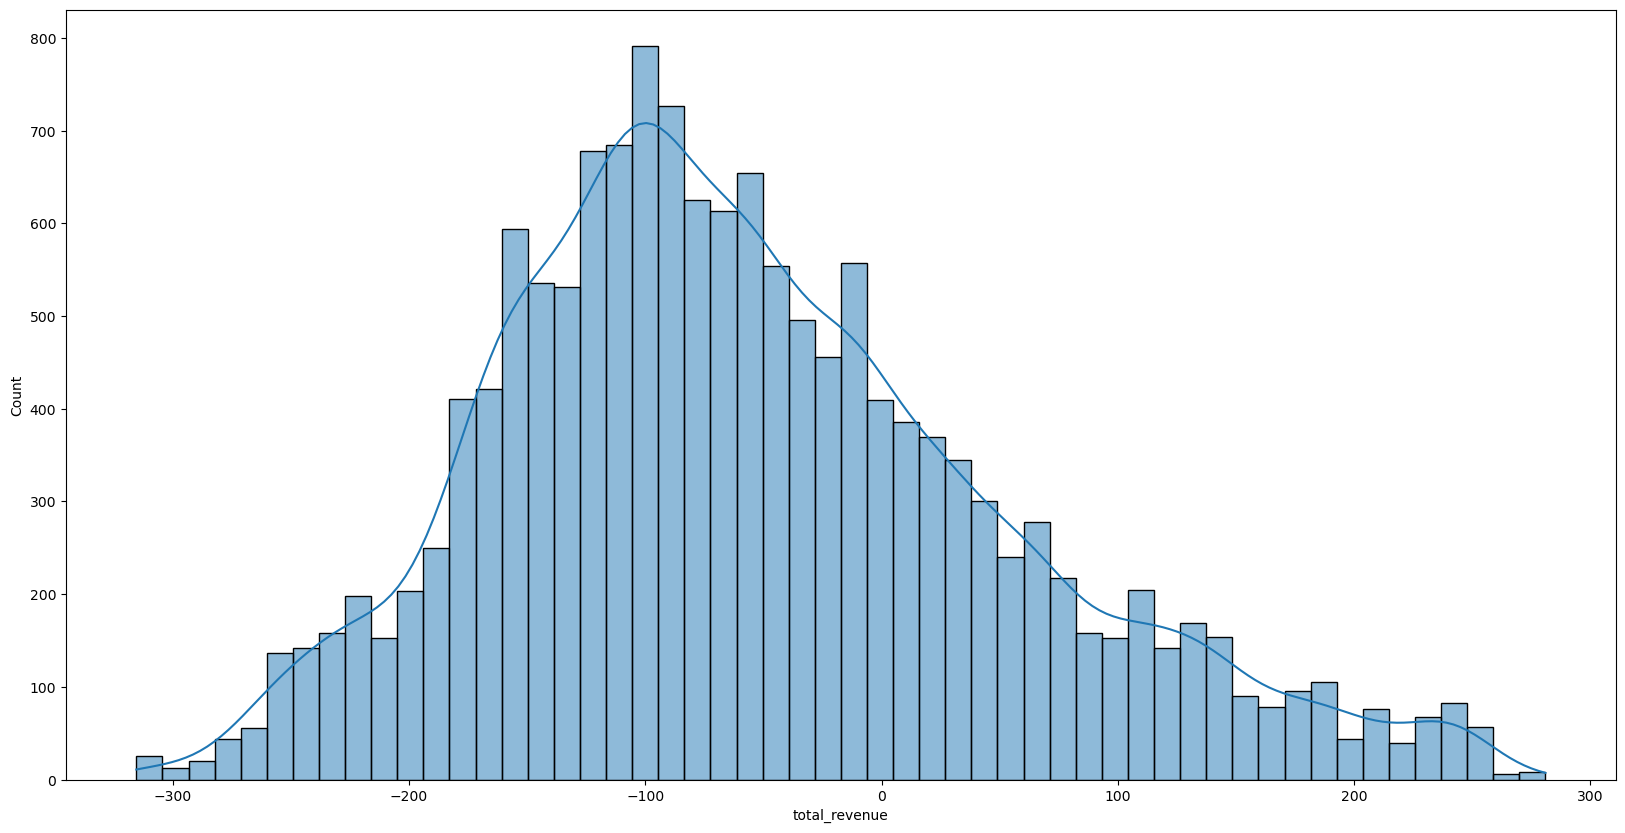

In [96]:
print("\nADABOOST Visualizations\n")

plt.figure(figsize=(20,10))
residuals = y_test - y_pred_test
sns.histplot(residuals, kde=True)

# GRADIENT BOOSTING
###### Gradient Boosting (GB) is an ensemble method like AdaBoost.
###### it builds trees sequentially, where each new tree tries to correct the errors (residuals) of the previous trees.1

In [97]:
gb_model=GradientBoostingRegressor(n_estimators=1000,learning_rate=0.1,random_state=50)
gb_model.fit(x_train,y_train)


GradientBoostingRegressor(n_estimators=1000, random_state=50)

In [98]:
y_pred_train=gb_model.predict(x_train)
y_pred_test=gb_model.predict(x_test)


In [99]:
print("\nGradient Boosting (GB)  Performance\n")
print(f"Train Score              : {gb_model.score(x_train, y_train):.4f}")
print(f"Test Score               : {gb_model.score(x_test, y_test):.4f}")
print(f"MSE                      : {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"MAE                      : {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"R² Score (Test Data)     : {r2_score(y_test, y_pred_test):.4f}")
print(f"Root Mean Squared Error  : {np.sqrt(mean_squared_error(y_test,y_pred_test)):.4f}")


Gradient Boosting (GB)  Performance

Train Score              : 0.9998
Test Score               : 0.9998
MSE                      : 61.3453
MAE                      : 5.8399
R² Score (Test Data)     : 0.9998
Root Mean Squared Error  : 7.8323



Gradient Boosting (GB)  Visualizations



<Axes: xlabel='total_revenue', ylabel='Count'>

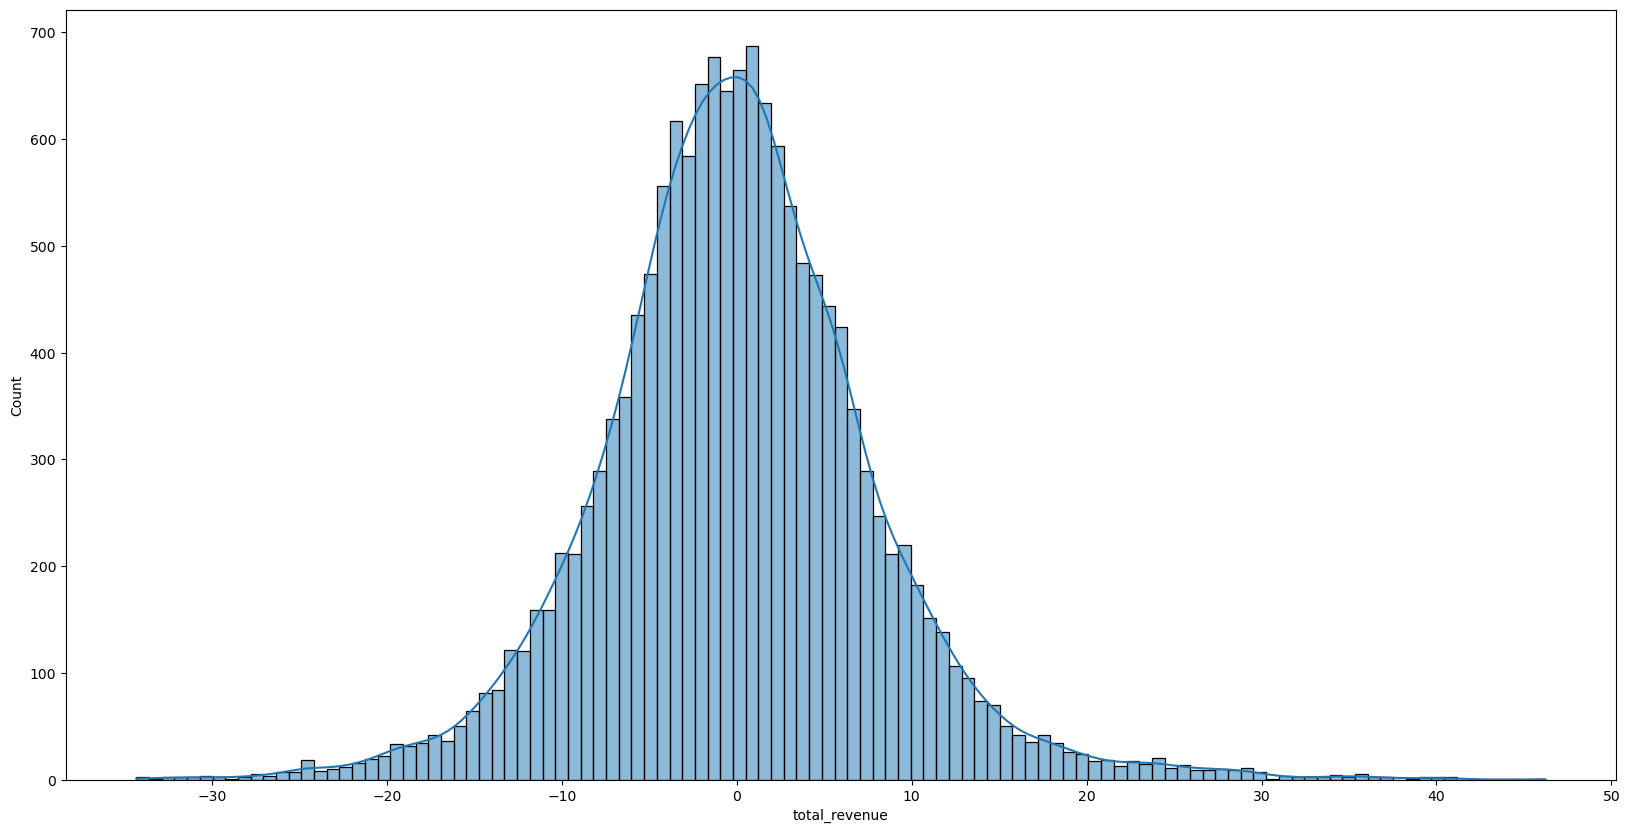

In [100]:
print("\nGradient Boosting (GB)  Visualizations\n")

plt.figure(figsize=(20,10))
residuals = y_test - y_pred_test
sns.histplot(residuals, kde=True)

# INITIAL PERFORMANCE

In [156]:
# 1. Define your models in a dictionary
models={
    'LINEAR REGRESSION': lr_model,
    'DECISION TREE': dt_model,
    'RANDOM FOREST': rf_model,
    'XG BOOST': xgb_model,
    'SVM': svm_model,
    'KNN': knn_model,
    'ADABOOST': ada_model,
    'GRADIENT BOOSTING': gb_model
}
# 2. Loop through and calculate metrics

results = []

for i , model in models.items():
    y_pred_test=model.predict(x_test)
    

    results.append({
        'MODEL':i,
        'R2_SCORE': r2_score(y_test, y_pred_test),
        'Train R2': model.score(x_train, y_train),
        'Test R2': model.score(x_test, y_test)
       
        
    })

dataframe=pd.DataFrame(results
                      ).set_index('MODEL').T.reset_index()
dataframe.rename(columns={'index':'SCORES'},inplace=True)
pd.DataFrame(results)

,MODEL,R2_SCORE,Train R2,Test R2
0,LINEAR REGRESSION,0.878845,0.880053,0.878845
1,DECISION TREE,0.999984,1.000000,0.999984
2,RANDOM FOREST,0.999841,0.999870,0.999841
3,XG BOOST,0.999920,0.999928,0.999920
4,SVM,0.861634,0.863021,0.861634
5,KNN,0.966823,0.976174,0.966823
6,ADABOOST,0.945313,0.945860,0.945313
7,GRADIENT BOOSTING,0.999774,0.999792,0.999774


# HYPERPARAMETER TUNNING

In [102]:
model1 = GridSearchCV(
    lr_model,
    param_grid = {'fit_intercept': [True, False]},
    cv=5,
    scoring='r2',   # since it's regression
    return_train_score=True)

model1.fit(x_train, y_train)


GridSearchCV(cv=5, estimator=LinearRegression(),
             param_grid={'fit_intercept': [True, False]},
             return_train_score=True, scoring='r2')

In [103]:
best_score_model1=model1.best_score_
best_score_model1

np.float64(0.8799513119221466)

In [104]:
best_params_model1 = model1.best_params_
best_params_model1

{'fit_intercept': True}

In [105]:
results = pd.DataFrame(model1.cv_results_)

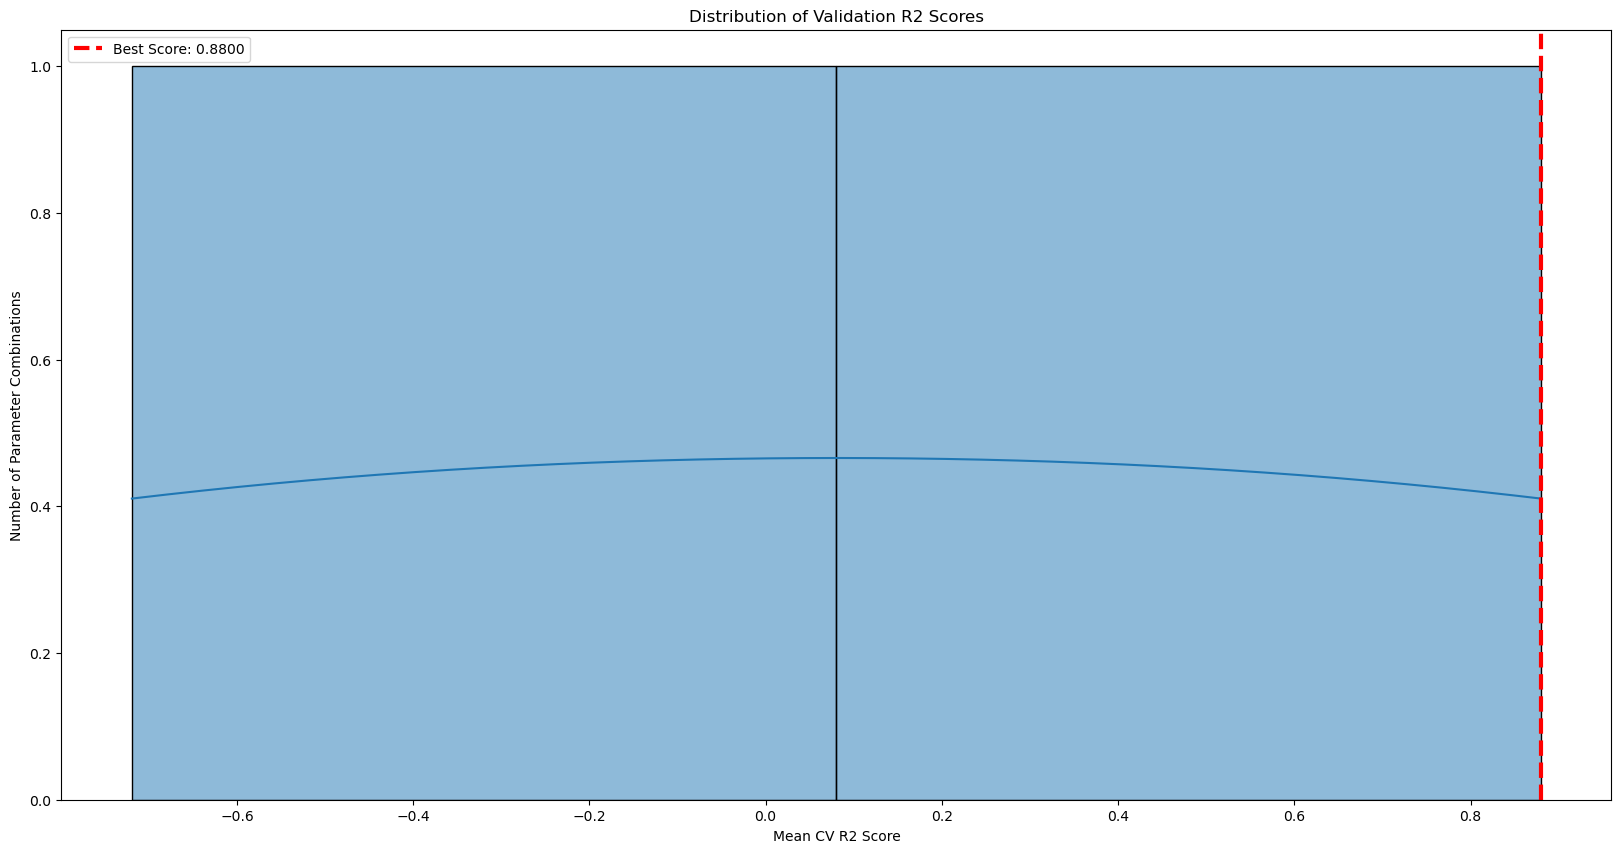

In [106]:
plt.figure(figsize=(20,10))

sns.histplot(results['mean_test_score'], kde=True)

best_score = results['mean_test_score'].max()

plt.axvline(best_score,                                          # Axis Vertical Line :- It draws a vertical reference line on your plot.
            color='red',
            linestyle='--',
            linewidth=3,
            label=f'Best Score: {best_score_model1:.4f}')

plt.legend()
plt.title('Distribution of Validation R2 Scores')
plt.xlabel('Mean CV R2 Score')
plt.ylabel('Number of Parameter Combinations')
plt.show()

In [107]:
model2 = GridSearchCV(dt_model, 
                      param_grid = {'criterion': ['squared_error'],'max_depth': [None, 5, 10, 20]}, 
                      cv=5,
                      scoring='r2',   # since it's regression
                      return_train_score=True)


model2.fit(x_train, y_train)


GridSearchCV(cv=5,
             estimator=DecisionTreeRegressor(criterion='friedman_mse',
                                             random_state=42),
             param_grid={'criterion': ['squared_error'],
                         'max_depth': [None, 5, 10, 20]},
             return_train_score=True, scoring='r2')

In [108]:
best_score_model2=model2.best_score_
best_score_model2

np.float64(0.9999742518834618)

In [109]:
best_params_model2 = model2.best_params_
best_params_model2

{'criterion': 'squared_error', 'max_depth': None}

In [110]:
results1 = pd.DataFrame(model2.cv_results_)

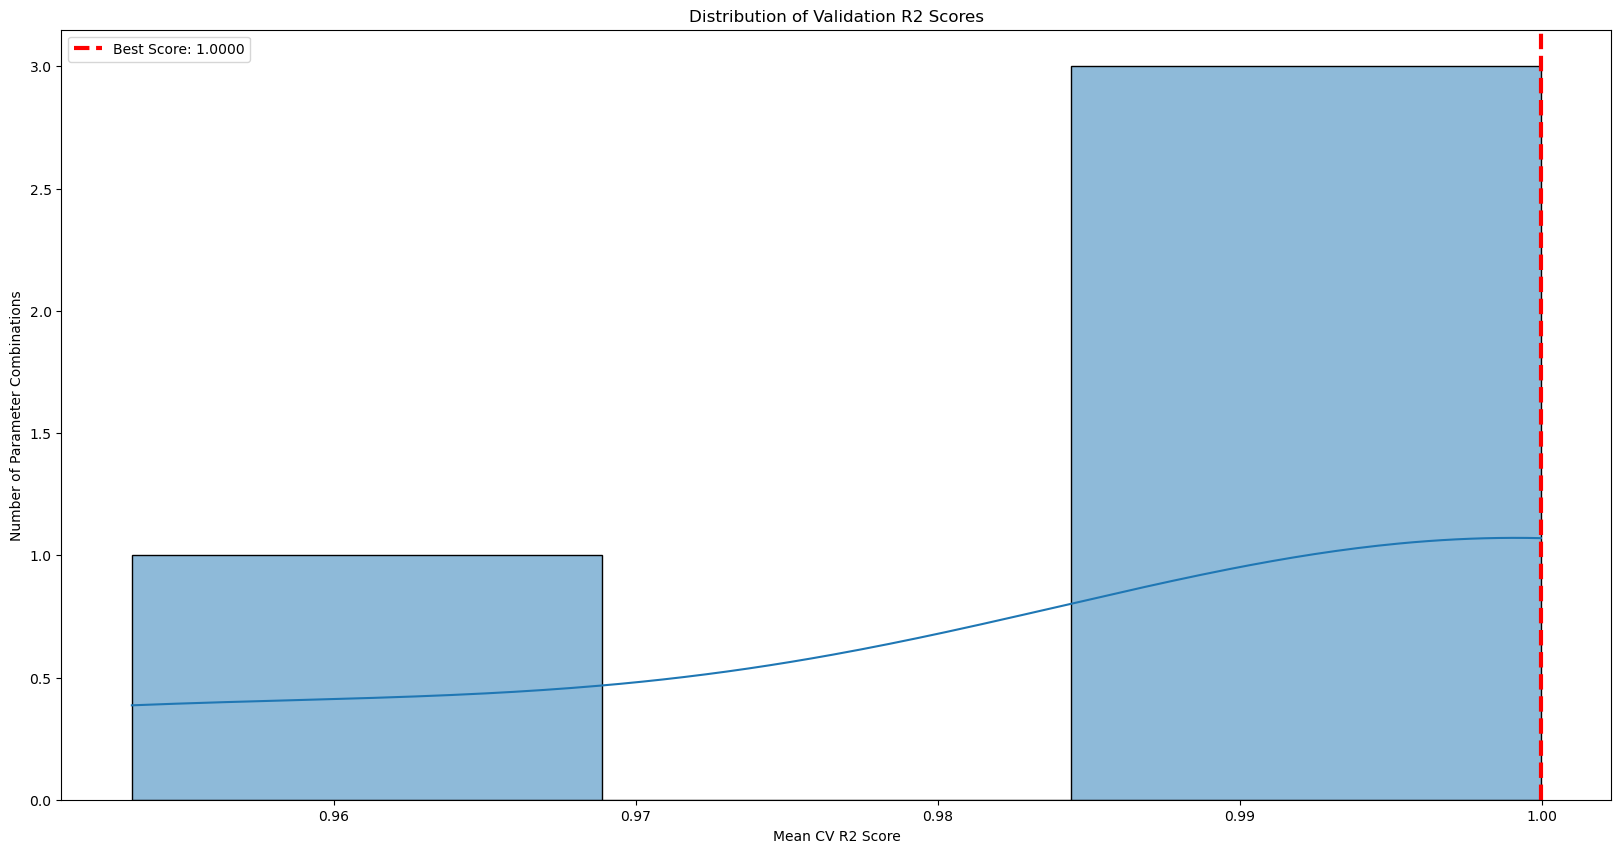

In [111]:
plt.figure(figsize=(20,10))

sns.histplot(results1['mean_test_score'], kde=True)

best_score = results1['mean_test_score'].max()

plt.axvline(best_score,                                          # Axis Vertical Line :- It draws a vertical reference line on your plot.
            color='red',
            linestyle='--',
            linewidth=3,
            label=f'Best Score: {best_score_model2:.4f}')

plt.legend()
plt.title('Distribution of Validation R2 Scores')
plt.xlabel('Mean CV R2 Score')
plt.ylabel('Number of Parameter Combinations')
plt.show()

In [112]:
model3 = GridSearchCV(rf_model,
                      param_grid = {'n_estimators': [50, 100, 200]},
                      cv=5, 
                      scoring='r2',   # since it's regression
                      return_train_score=True)


model3.fit(x_train, y_train)



GridSearchCV(cv=5,
             estimator=RandomForestRegressor(max_depth=10, random_state=42),
             param_grid={'n_estimators': [50, 100, 200]},
             return_train_score=True, scoring='r2')

In [113]:
best_score_model3=model3.best_score_
best_score_model3

np.float64(0.9998343044489036)

In [114]:
best_params_model3 = model3.best_params_
best_params_model3

{'n_estimators': 200}

In [115]:
results2 = pd.DataFrame(model3.cv_results_)

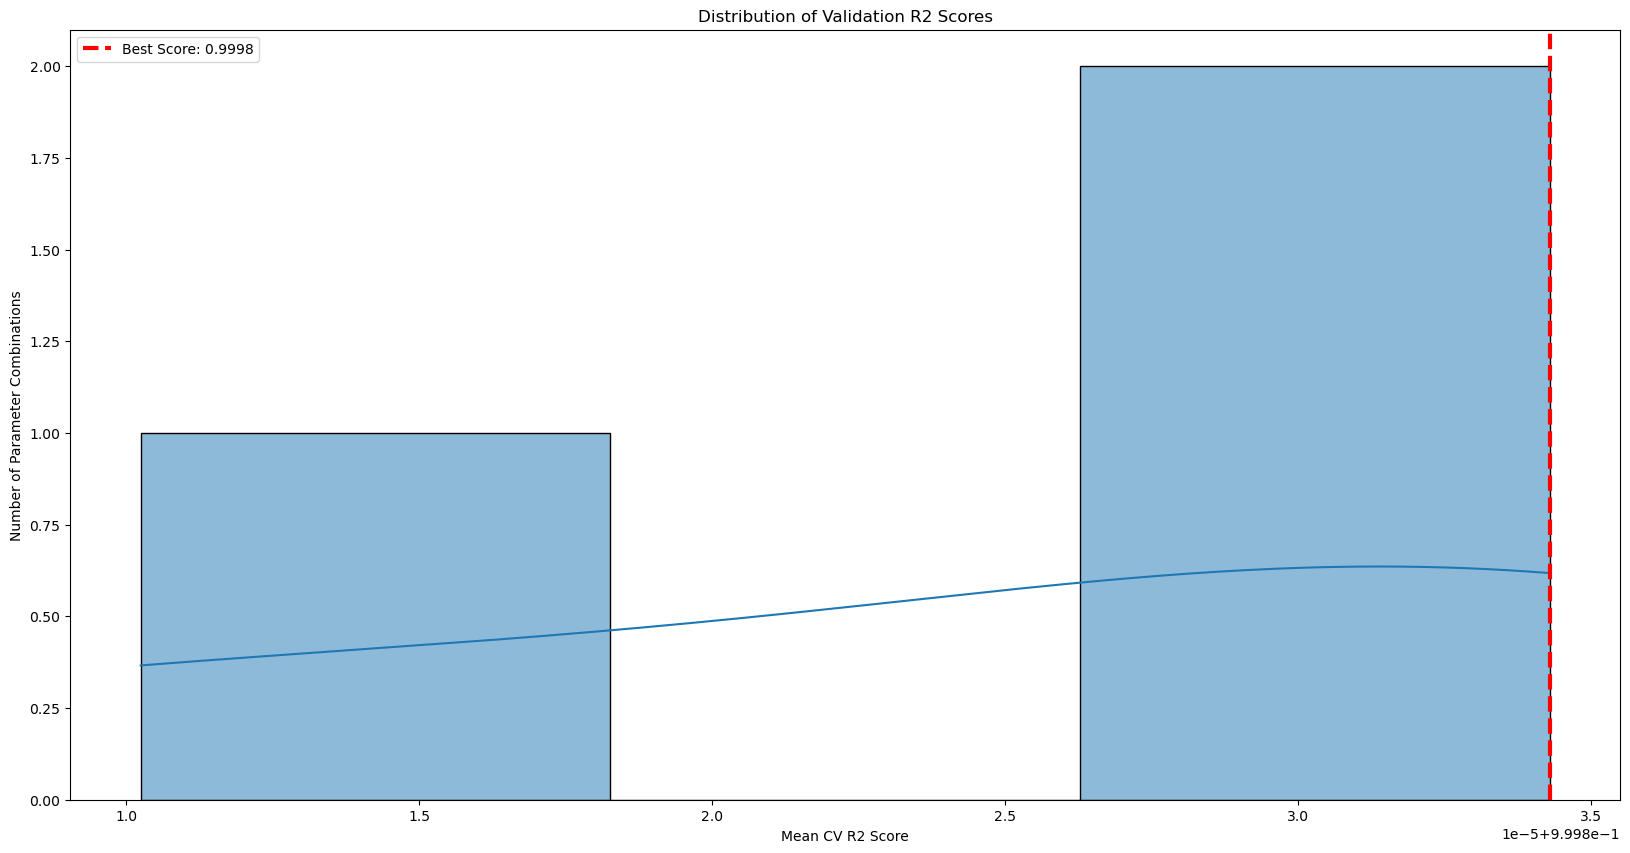

In [116]:
plt.figure(figsize=(20,10))

sns.histplot(results2['mean_test_score'], kde=True)

best_score = results2['mean_test_score'].max()

plt.axvline(best_score,                                          # Axis Vertical Line :- It draws a vertical reference line on your plot.
            color='red',
            linestyle='--',
            linewidth=3,
            label=f'Best Score: {best_score_model3:.4f}')

plt.legend()
plt.title('Distribution of Validation R2 Scores')
plt.xlabel('Mean CV R2 Score')
plt.ylabel('Number of Parameter Combinations')
plt.show()

In [117]:
model4=GridSearchCV(xgb_model,
                    param_grid = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1]},
                    cv=5,
                    scoring='r2',   # since it's regression
                    return_train_score=True)

model4.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=0.05, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=200,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1],
                         'n_estimators': [100, 200]},
             return_train_score=True, scoring='r2')

In [118]:
best_score_model4=model4.best_score_
best_score_model4

np.float64(0.9999172693977826)

In [119]:
best_params_model4 = model4.best_params_
best_params_model4

{'learning_rate': 0.1, 'n_estimators': 200}

In [120]:
results3 = pd.DataFrame(model4.cv_results_)

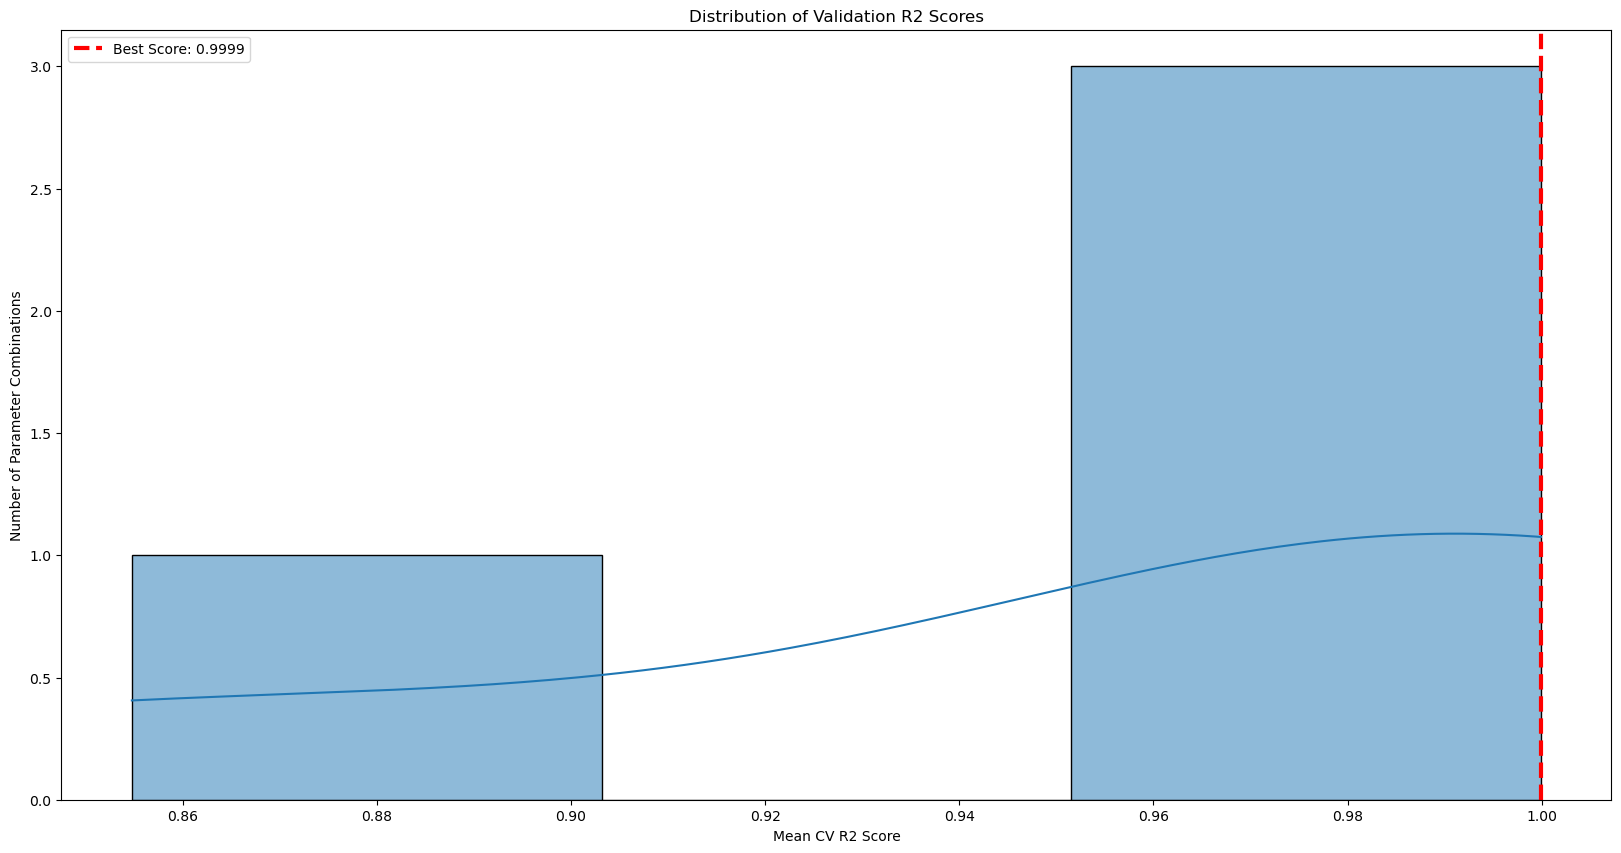

In [121]:
plt.figure(figsize=(20,10))

sns.histplot(results3['mean_test_score'], kde=True)

best_score = results3['mean_test_score'].max()

plt.axvline(best_score,                                          # Axis Vertical Line :- It draws a vertical reference line on your plot.
            color='red',
            linestyle='--',
            linewidth=3,
            label=f'Best Score: {best_score_model4:.4f}')

plt.legend()
plt.title('Distribution of Validation R2 Scores')
plt.xlabel('Mean CV R2 Score')
plt.ylabel('Number of Parameter Combinations')
plt.show()

In [123]:
model5 = GridSearchCV(
    estimator=svm_model,
    param_grid={
        'gamma': ['auto', 'scale'],
        'C': [1, 5, 10, 20],
        'kernel': ['linear', 'rbf' ]
    },
    cv=5,
    scoring='r2',   # regression metric
    return_train_score=True,
    n_jobs=-1
)

model5.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=SVR(C=1, kernel='linear', max_iter=10000),
             n_jobs=-1,
             param_grid={'C': [1, 5, 10, 20], 'gamma': ['auto', 'scale'],
                         'kernel': ['linear', 'rbf']},
             return_train_score=True, scoring='r2')

In [124]:
best_score_model5=model5.best_score_
best_score_model5 

np.float64(0.9963507543418316)

In [125]:
best_params_model5 = model5.best_params_
best_params_model5

{'C': 20, 'gamma': 'scale', 'kernel': 'rbf'}

In [126]:
results4 = pd.DataFrame(model5.cv_results_)

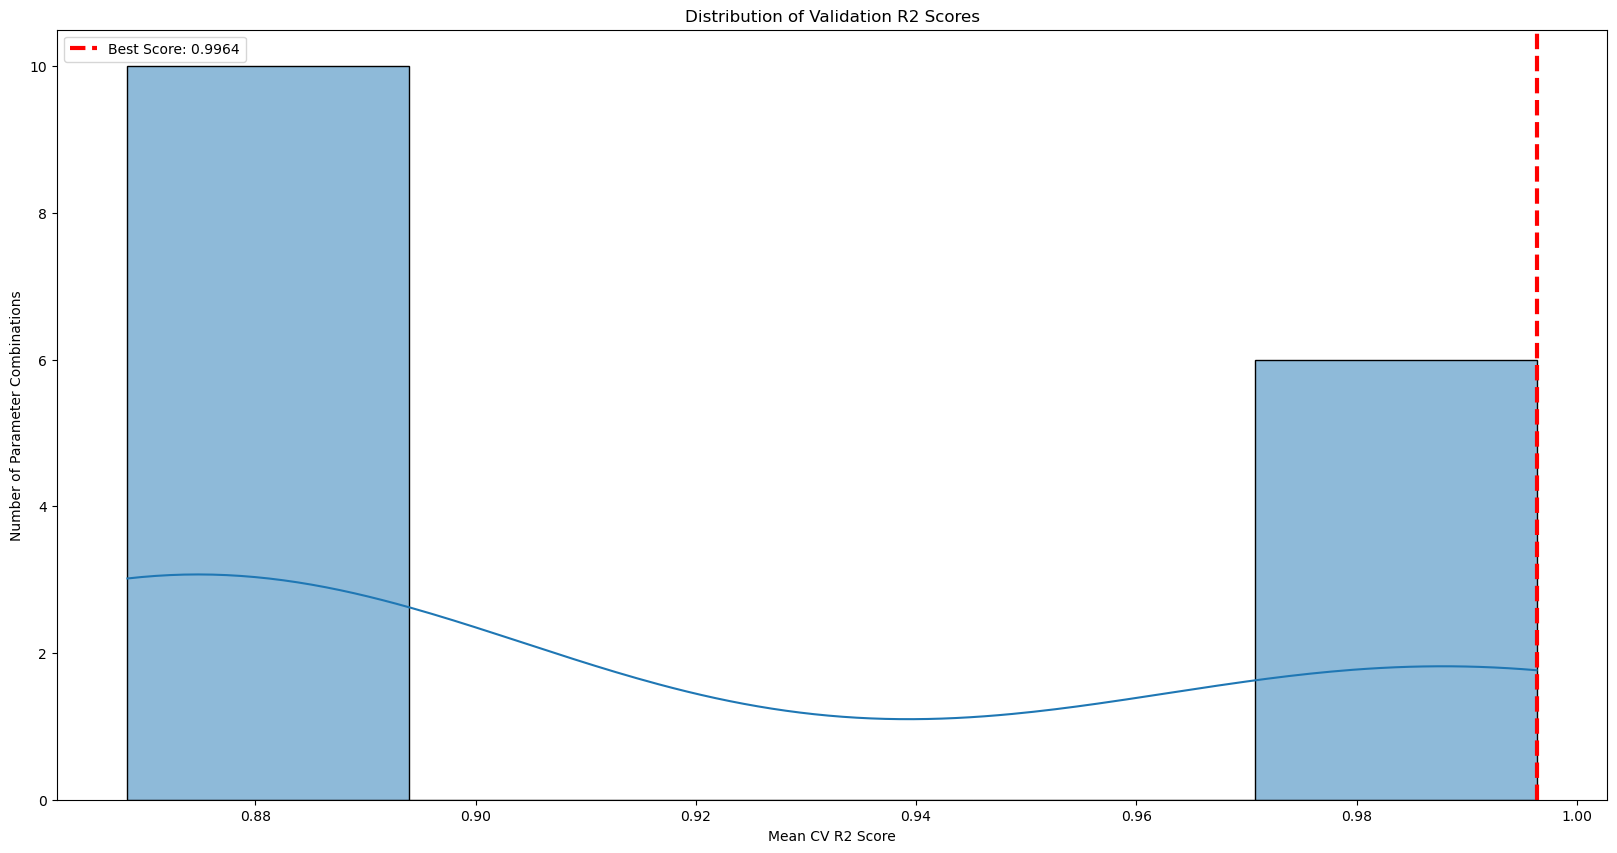

In [127]:
plt.figure(figsize=(20,10))

sns.histplot(results4['mean_test_score'], kde=True)

best_score = results4['mean_test_score'].max()

plt.axvline(best_score,                                          # Axis Vertical Line :- It draws a vertical reference line on your plot.
            color='red',
            linestyle='--',
            linewidth=3,
            label=f'Best Score: {best_score_model5:.4f}')

plt.legend()
plt.title('Distribution of Validation R2 Scores')
plt.xlabel('Mean CV R2 Score')
plt.ylabel('Number of Parameter Combinations')
plt.show()

In [128]:
model6= GridSearchCV(knn_model, 
                     param_grid = {'n_neighbors': [3, 5, 7, 9, 11]},
                     cv=5,
                     scoring='r2',   # since it's regression
                     return_train_score=True)

model6.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(n_jobs=-1),
             param_grid={'n_neighbors': [3, 5, 7, 9, 11]},
             return_train_score=True, scoring='r2')

In [129]:
best_score_model6=model6.best_score_
best_score_model6

np.float64(0.9701664431213566)

In [130]:
best_params_model6 = model6.best_params_
best_params_model6

{'n_neighbors': 11}

In [131]:
results5 = pd.DataFrame(model6.cv_results_)

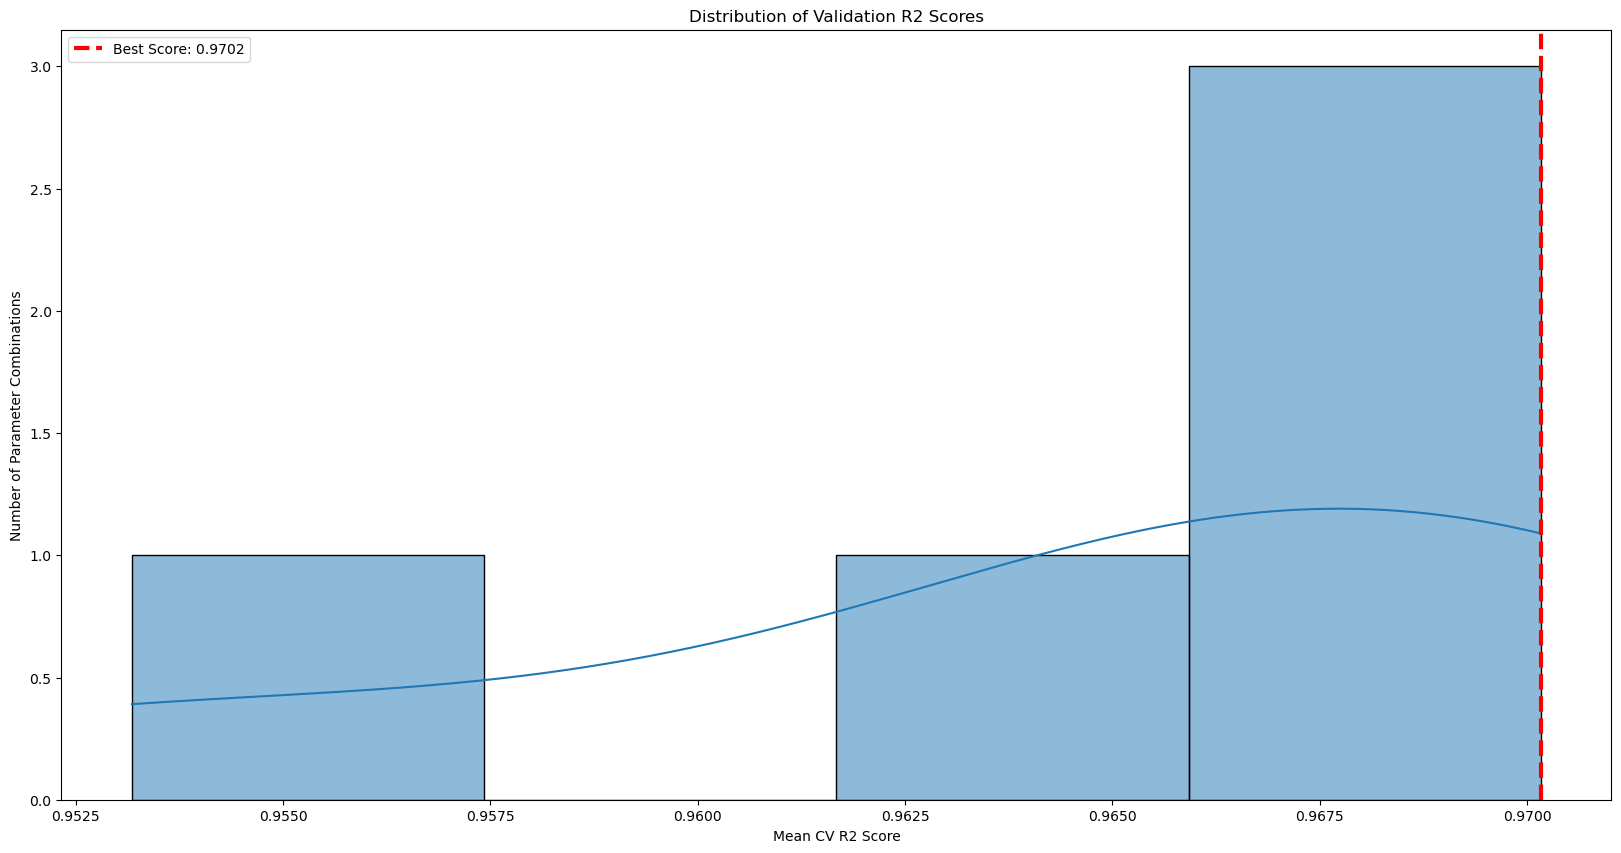

In [132]:
plt.figure(figsize=(20,10))

sns.histplot(results5['mean_test_score'], kde=True)

best_score = results5['mean_test_score'].max()

plt.axvline(best_score,                                          # Axis Vertical Line :- It draws a vertical reference line on your plot.
            color='red',
            linestyle='--',
            linewidth=3,
            label=f'Best Score: {best_score_model6:.4f}')

plt.legend()
plt.title('Distribution of Validation R2 Scores')
plt.xlabel('Mean CV R2 Score')
plt.ylabel('Number of Parameter Combinations')
plt.show()

In [133]:
model7 = GridSearchCV(ada_model,
                         param_grid = {'n_estimators': [50, 100, 200],'learning_rate': [0.01, 0.1, 1]},
                         cv=5,
                         scoring='r2',   # since it's regression
                         return_train_score=True)

model7.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=AdaBoostRegressor(learning_rate=0.1, n_estimators=1000,
                                         random_state=50),
             param_grid={'learning_rate': [0.01, 0.1, 1],
                         'n_estimators': [50, 100, 200]},
             return_train_score=True, scoring='r2')

In [134]:
best_score_model7=model7.best_score_
best_score_model7

np.float64(0.9521095883310651)

In [135]:
best_params_model7 = model7.best_params_
best_params_model7

{'learning_rate': 1, 'n_estimators': 100}

In [136]:
results6 = pd.DataFrame(model7.cv_results_)

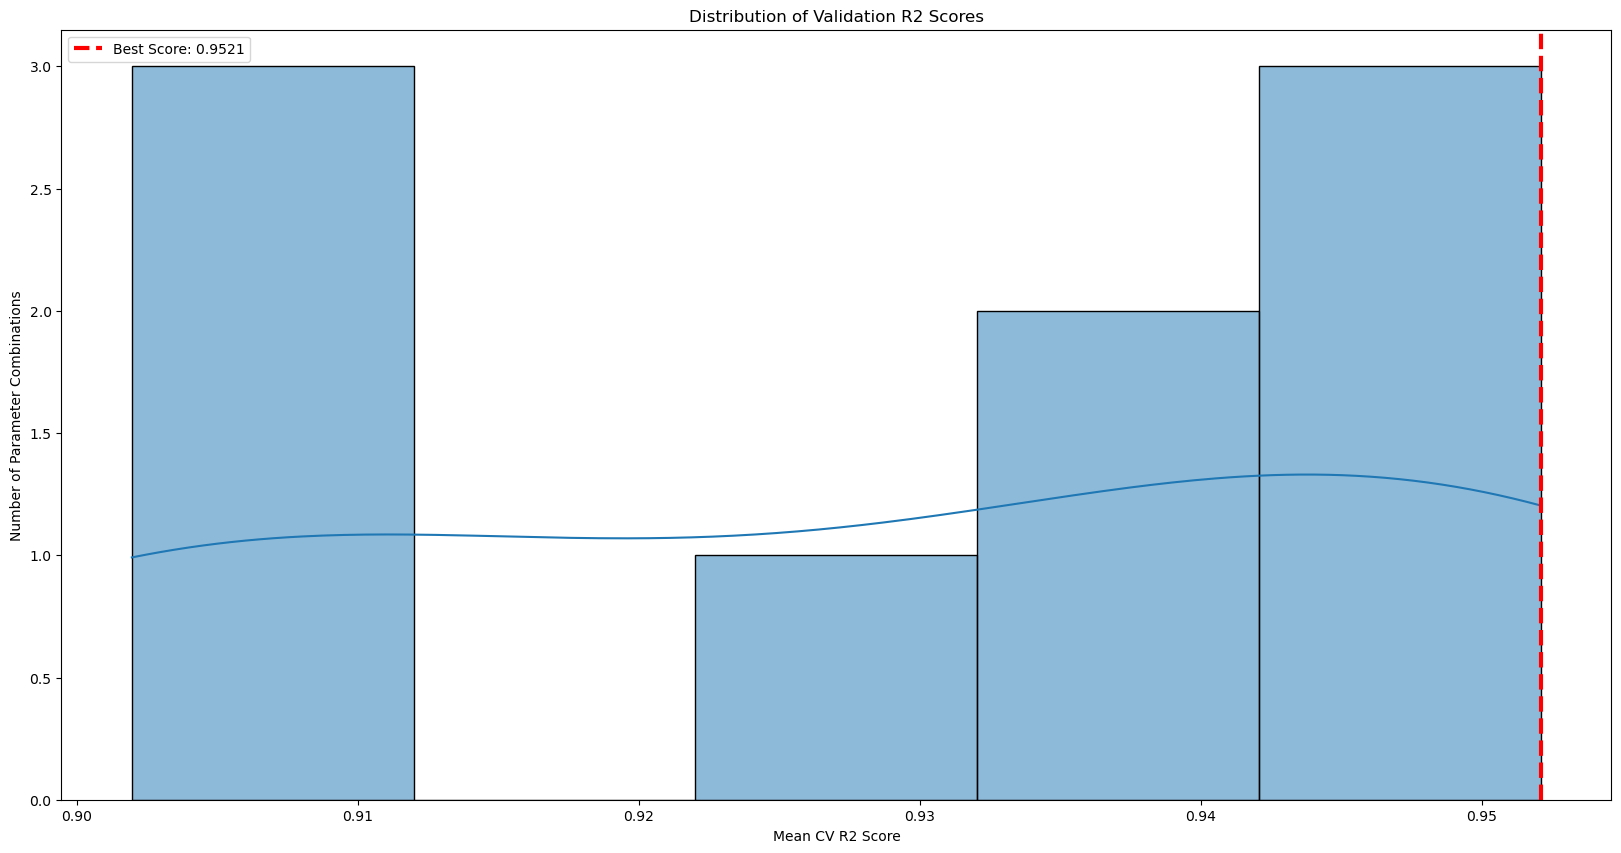

In [137]:
plt.figure(figsize=(20,10))

sns.histplot(results6['mean_test_score'], kde=True)

best_score = results6['mean_test_score'].max()

plt.axvline(best_score,                                          # Axis Vertical Line :- It draws a vertical reference line on your plot.
            color='red',
            linestyle='--',
            linewidth=3,
            label=f'Best Score: {best_score_model7:.4f}')

plt.legend()
plt.title('Distribution of Validation R2 Scores')
plt.xlabel('Mean CV R2 Score')
plt.ylabel('Number of Parameter Combinations')
plt.show()

In [138]:
model8 = GridSearchCV(gb_model, 
                       param_grid = {'n_estimators': [100, 200],'learning_rate': [0.01, 0.1]},
                       cv=5, 
                       scoring='r2',   # since it's regression
                       return_train_score=True)


model8.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=GradientBoostingRegressor(n_estimators=1000,
                                                 random_state=50),
             param_grid={'learning_rate': [0.01, 0.1],
                         'n_estimators': [100, 200]},
             return_train_score=True, scoring='r2')

In [139]:
best_score_model8=model8.best_score_
best_score_model8

np.float64(0.9990954885842832)

In [140]:
best_params_model8 = model8.best_params_
best_params_model8

{'learning_rate': 0.1, 'n_estimators': 200}

In [141]:
results7 = pd.DataFrame(model8.cv_results_)

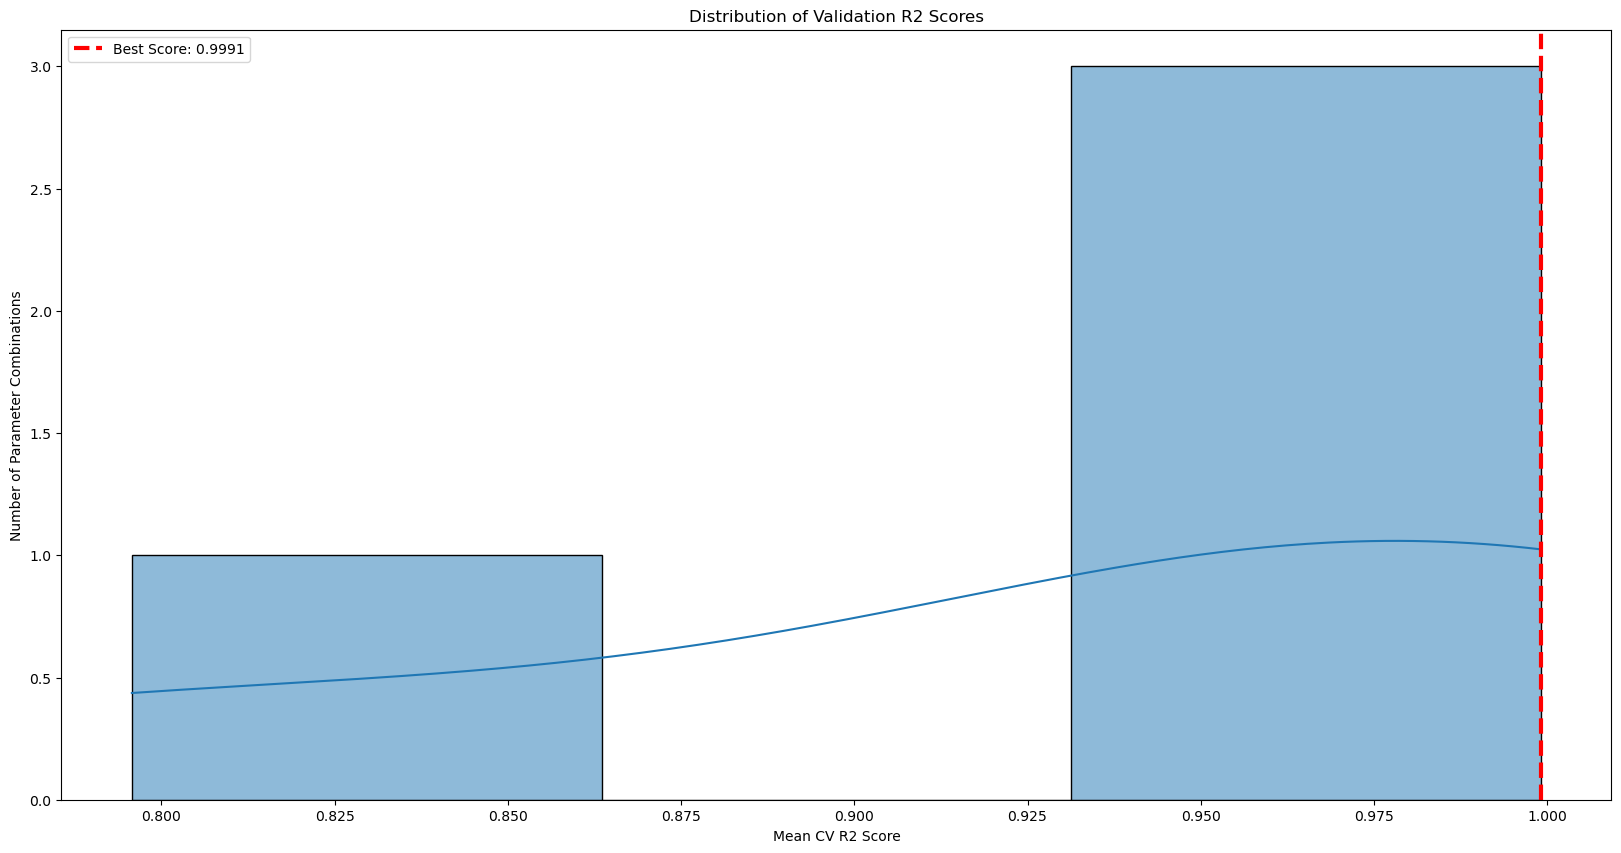

In [142]:
plt.figure(figsize=(20,10))

sns.histplot(results7['mean_test_score'], kde=True)

best_score = results7['mean_test_score'].max()

plt.axvline(best_score,                                          # Axis Vertical Line :- It draws a vertical reference line on your plot.
            color='red',
            linestyle='--',
            linewidth=3,
            label=f'Best Score: {best_score_model8:.4f}')

plt.legend()
plt.title('Distribution of Validation R2 Scores')
plt.xlabel('Mean CV R2 Score')
plt.ylabel('Number of Parameter Combinations')
plt.show()

In [143]:
all_models = {
    'LINEAR REGRESSION': model1,
    'DECISION TREE': model2,
    'RANDOM FOREST': model3,
    'XG BOOST': model4,
    'SVM': model5,
    'KNN': model6,
    'ADABOOST': model7,
    'GRADIENT BOOSTING': model8
}

summary = []

for name, model in all_models.items():
    summary.append({
        "Model": name,
        "Best Score": model.best_score_,
        "BEST PARAMS": model.best_params_
       
    })

dataframe1=pd.DataFrame(summary).set_index('Model').T.reset_index()
dataframe1.rename(columns={'index':'SCORES'},inplace=True)
pd.DataFrame(summary)

,Model,Best Score,BEST PARAMS
0,LINEAR REGRESSION,0.879951,{'fit_intercept': True}
1,DECISION TREE,0.999974,"{'criterion': 'squared_error', 'max_depth': None}"
2,RANDOM FOREST,0.999834,{'n_estimators': 200}
3,XG BOOST,0.999917,"{'learning_rate': 0.1, 'n_estimators': 200}"
4,SVM,0.996351,"{'C': 20, 'gamma': 'scale', 'kernel': 'rbf'}"
5,KNN,0.970166,{'n_neighbors': 11}
6,ADABOOST,0.952110,"{'learning_rate': 1, 'n_estimators': 100}"
7,GRADIENT BOOSTING,0.999095,"{'learning_rate': 0.1, 'n_estimators': 200}"


# Model Performance Evaluation:- DECISION TREE

In [185]:
best_model = model3.best_estimator_
train_r2 = best_model.score(x_train, y_train)
print("Train R2:", train_r2)

Train R2: 0.9998737684819016


In [186]:
test_r2 = best_model.score(x_test, y_test)
print("Test R2:", test_r2)

Test R2: 0.9998450844934599


In [187]:
y_pred = best_model.predict(x_test)

In [188]:
y_pred

array([1727.34274394,  693.56980618,  470.72482235, ...,   87.28075015,
        381.57187607, 1812.99428312])

In [190]:
import joblib

# Save model
joblib.dump(best_model, 'revenue_model.pkl', compress=3)

# Save scaler
joblib.dump(sc, 'scaler.pkl')

# Save label encoders
label_encoders = {
    'product_category': le,
    'customer_region': le1,
    'payment_method': le2
}

joblib.dump(label_encoders, 'label_encoders.pkl')

joblib.dump(x.columns, "model_columns.pkl")

['model_columns.pkl']

In [189]:
import os
os.remove("revenue_model.pkl")
os.remove("scaler.pkl")
os.remove("label_encoders.pkl")
os.remove("model_columns.pkl")